# DSMarket - First look at input files

## 1. Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder

from prophet import Prophet
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

c:\Users\jonmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 2. Paths and directories

In [2]:
sales_data_path = r"data\item_sales.csv"
calendar_data_path = r"data\daily_calendar_with_events.csv"
prices_data_path = r"data\item_prices.csv"

## 3. Import files

### 3A. Sales data

In [3]:
pd_sales = pd.read_csv(sales_data_path, sep = ",")
print("The shape of the sales datataframe is :", pd_sales.shape)

The shape of the sales datataframe is : (30490, 1920)


In [4]:
pd_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [5]:
pd_sales.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 1920 columns):
 #     Column      Dtype 
---    ------      ----- 
 0     id          object
 1     item        object
 2     category    object
 3     department  object
 4     store       object
 5     store_code  object
 6     region      object
 7     d_1         int64 
 8     d_2         int64 
 9     d_3         int64 
 10    d_4         int64 
 11    d_5         int64 
 12    d_6         int64 
 13    d_7         int64 
 14    d_8         int64 
 15    d_9         int64 
 16    d_10        int64 
 17    d_11        int64 
 18    d_12        int64 
 19    d_13        int64 
 20    d_14        int64 
 21    d_15        int64 
 22    d_16        int64 
 23    d_17        int64 
 24    d_18        int64 
 25    d_19        int64 
 26    d_20        int64 
 27    d_21        int64 
 28    d_22        int64 
 29    d_23        int64 
 30    d_24        int64 
 31    d_25        int64 
 32  

How many **stores** are there in the data?

In [6]:
print("There are {} stores in the data, and the number of registers per store are: ".format(pd_sales.store.nunique()))
pd_sales.store.value_counts()

There are 10 stores in the data, and the number of registers per store are: 


store
Greenwich_Village    3049
Harlem               3049
Tribeca              3049
Brooklyn             3049
South_End            3049
Roxbury              3049
Back_Bay             3049
Midtown_Village      3049
Yorktown             3049
Queen_Village        3049
Name: count, dtype: int64

How many **items**?

In [7]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_sales.item.nunique()))
pd_sales.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
SUPERMARKET_3_827    10
ACCESORIES_1_001     10
ACCESORIES_1_002     10
ACCESORIES_1_003     10
ACCESORIES_1_004     10
                     ..
ACCESORIES_1_013     10
ACCESORIES_1_014     10
ACCESORIES_1_015     10
ACCESORIES_1_016     10
ACCESORIES_1_017     10
Name: count, Length: 3049, dtype: int64

And **departments**?

In [8]:
print("There are {} departments in the data, and the number of registers per department are: ".format(pd_sales.department.nunique()))
pd_sales.department.value_counts()

There are 7 departments in the data, and the number of registers per department are: 


department
SUPERMARKET_3      8230
HOME_&_GARDEN_1    5320
HOME_&_GARDEN_2    5150
ACCESORIES_1       4160
SUPERMARKET_2      3980
SUPERMARKET_1      2160
ACCESORIES_2       1490
Name: count, dtype: int64

Do we have one register per id? In other words, can two registers have the same id?

In [9]:
print(pd_sales.shape)
print(pd_sales.id.drop_duplicates().shape)

(30490, 1920)
(30490,)


In [10]:
pd_sales[pd_sales.id == 'ACCESORIES_1_002_NYC_1'].T

,1
id,ACCESORIES_1_002_NYC_1
item,ACCESORIES_1_002
category,ACCESORIES
department,ACCESORIES_1
store,Greenwich_Village
...,...
d_1909,1
d_1910,0
d_1911,0
d_1912,0


In [11]:
pd_sales.isnull().sum().sort_values(ascending=True)

d_1906    0
d_1907    0
d_1908    0
d_1909    0
d_1910    0
         ..
d_29      0
d_30      0
d_31      0
d_32      0
d_33      0
Length: 1920, dtype: int64

### 3B. Calendar data

In [12]:
pd_calendar = pd.read_csv(calendar_data_path, sep = ",")
print("The shape of the calendar datataframe is :", pd_calendar.shape)

The shape of the calendar datataframe is : (1913, 5)


In [13]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [14]:
pd_calendar.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1913 non-null   object
 1   weekday      1913 non-null   object
 2   weekday_int  1913 non-null   int64 
 3   d            1913 non-null   object
 4   event        26 non-null     object
dtypes: int64(1), object(4)
memory usage: 74.9+ KB


In [15]:
print("The range of dates available are: {} - {}".format(pd_calendar['date'].min(),pd_calendar['date'].max()))

The range of dates available are: 2011-01-29 - 2016-04-24


What sort of events do we have?

In [16]:
pd_calendar.event.value_counts(dropna=False)

event
NaN               1887
SuperBowl            6
Ramadan starts       5
Thanksgiving         5
NewYear              5
Easter               5
Name: count, dtype: int64

We don't have a lot of events, but we can think about including additional ones in a later stage (it might help!)

### 3C. Prices data

In [17]:
pd_prices = pd.read_csv(prices_data_path, sep = ",")
print("The shape of the prices datataframe is :", pd_prices.shape)

The shape of the prices datataframe is : (6965706, 5)


In [18]:
pd_prices.head()

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.00",12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.00",12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.00",10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,331.00",10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,332.00",10.99


In [19]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), object(3)
memory usage: 265.7+ MB


Same number of items in the prices data?

In [20]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_prices.item.nunique()))
pd_prices.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
HOME_&_GARDEN_2_142    2870
HOME_&_GARDEN_2_193    2870
ACCESORIES_1_038       2870
HOME_&_GARDEN_2_184    2870
ACCESORIES_1_067       2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

The number of items does match, but there are many registers per item. It seems that prices per item can change with time

Let's take a loook at the variables distribution of the prices dataframe

In [21]:
pd_prices.describe()

,yearweek,sell_price
count,"6,721,786.00","6,965,706.00"
mean,"201,382.42",5.52
std,145.02,4.39
min,"201,105.00",0.01
25%,"201,248.00",2.62
50%,"201,410.00",4.20
75%,"201,515.00",7.18
max,"201,617.00",134.15


In [22]:
pd_prices.describe(include=['object'])

,item,category,store_code
count,6965706,6965706,6965706
unique,3049,3,10
top,HOME_&_GARDEN_2_142,SUPERMARKET,BOS_2
freq,2870,3239821,713960


In [23]:
pd_prices.yearweek.isnull().sum()/pd_prices.shape[0]

np.float64(0.03501726888846586)

In [24]:
pd_prices.loc[pd_prices['yearweek'].isnull()]

,item,category,store_code,yearweek,sell_price
149,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
150,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
151,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
152,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
153,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20


Dropping the Nan in yearweek (3.5%)
yearweek to int to be mergeable with calendar 

In [25]:
pd_prices = pd_prices.dropna(subset=['yearweek'])
pd_prices['yearweek'] = pd_prices['yearweek'].astype(int)

In [26]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 6721786 entries, 0 to 6965697
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 307.7+ MB


In [27]:
pd_prices['sell_price'].isnull().sum()/pd_prices.shape[0]

np.float64(0.0)

In [28]:
pd_prices.reset_index(drop=True, inplace=True)

In [29]:
pd_prices_sorted = pd_prices.sort_values(by=['item', 'store_code','yearweek']).reset_index(drop=True)

In [30]:
pd_prices_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6721786 entries, 0 to 6721785
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 256.4+ MB


## 4. Table management for merge

### 4.1. Yearweek & Events add to Calendar 

In [31]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [32]:
pd_calendar['event'] = pd_calendar['event'].fillna("NoEvent")

In [33]:
pd_calendar.isnull().sum()

date           0
weekday        0
weekday_int    0
d              0
event          0
dtype: int64

In [34]:
from datetime import datetime, timedelta
def weekyearnum(dt):
    return dt.strftime("%Y%W")

def myweekyearnum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weekyearnum(offsetdt)

def weeknum(dt):
    return dt.isocalendar()[1]

def myweeknum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weeknum(offsetdt)

In [35]:
## Merge
pd_calendar['date'] = pd.to_datetime(pd_calendar['date'], format = "%Y-%m-%d")

pd_calendar['yearweek'] = pd_calendar['date'].apply(lambda x: myweekyearnum(x)).astype(int)

In [36]:
pd_calendar.loc[pd_calendar['event']=="Ramadan starts"]

,date,weekday,weekday_int,d,event,yearweek
184,2011-08-01,Monday,3,d_185,Ramadan starts,201131
538,2012-07-20,Friday,7,d_539,Ramadan starts,201229
892,2013-07-09,Tuesday,4,d_893,Ramadan starts,201327
1247,2014-06-29,Sunday,2,d_1248,Ramadan starts,201426
1601,2015-06-18,Thursday,6,d_1602,Ramadan starts,201524


#### is_Ramadan, Christmas, 4th July

In [37]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 25) & (pd_calendar['date'].dt.month == 12), 'event'] = "Christmas"

In [38]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 4) & (pd_calendar['date'].dt.month == 7), 'event'] = "Independence_Day"

In [39]:
pd_calendar['is_Ramadan'] = 0

ramadan_starts = pd_calendar.loc[pd_calendar['event'] == 'Ramadan starts', 'date']

for start_date in ramadan_starts:
    mask = (pd_calendar['date'] >= start_date) & (pd_calendar['date'] < start_date + pd.Timedelta(days=30))
    
    pd_calendar.loc[
        mask,
        'is_Ramadan'
    ] = 1

In [40]:
pd_calendar.rename(columns={'d': 'day'}, inplace=True)

In [41]:
pd_calendar['is_Event'] = pd_calendar['event'].apply(lambda x: 0 if x == "NoEvent" else 1)

In [42]:
#pd_calendar['event_dow'] = pd_calendar.apply(lambda row: row['weekday_int'] if row['is_Event'] == 1 else -1, axis=1)

In [43]:
pd_calendar.sample(20)


,date,weekday,weekday_int,day,event,yearweek,is_Ramadan,is_Event
525,2012-07-07,Saturday,1,d_526,NoEvent,201228,0,0
1908,2016-04-20,Wednesday,5,d_1909,NoEvent,201616,0,0
1564,2015-05-12,Tuesday,4,d_1565,NoEvent,201519,0,0
306,2011-12-01,Thursday,6,d_307,NoEvent,201148,0,0
404,2012-03-08,Thursday,6,d_405,NoEvent,201210,0,0
1308,2014-08-29,Friday,7,d_1309,NoEvent,201434,0,0
1381,2014-11-10,Monday,3,d_1382,NoEvent,201445,0,0
1827,2016-01-30,Saturday,1,d_1828,NoEvent,201605,0,0
1034,2013-11-28,Thursday,6,d_1035,Thanksgiving,201347,0,1
482,2012-05-25,Friday,7,d_483,NoEvent,201221,0,0


In [44]:
pd_calendar['event_clean'] = pd_calendar['event'].replace("NoEvent", np.nan)

In [45]:
pd_calendar = pd_calendar.sort_values(['yearweek', 'date'])
weekly_calendar = (
    pd_calendar
    .groupby('yearweek')
    .agg(
        event_count=('is_Event', 'sum'),
        ramadan_count=('is_Ramadan', 'sum'),
        first_event=('event', lambda x: x[x != 'NoEvent'].iloc[0] 
                     if (x != 'NoEvent').any() else 'NoEvent'),
        first_event_dow=('event', lambda x: 
            pd_calendar.loc[x.index[x != 'NoEvent'][0], 'weekday_int']
            if (x != 'NoEvent').any() else -1),
        event_on_weekend=('weekday_int', lambda x: int(any((pd_calendar.loc[x.index, 'weekday_int'] <= 2) & 
                    (pd_calendar.loc[x.index, 'is_Event'] == 1))))
    )
    .reset_index()
)

In [46]:
weekly_calendar

,yearweek,event_count,ramadan_count,first_event,first_event_dow,event_on_weekend
0,201105,0,0,NoEvent,-1,0
1,201106,1,0,SuperBowl,2,1
2,201107,0,0,NoEvent,-1,0
3,201108,0,0,NoEvent,-1,0
4,201109,0,0,NoEvent,-1,0
5,201110,0,0,NoEvent,-1,0
6,201111,0,0,NoEvent,-1,0
7,201112,0,0,NoEvent,-1,0
8,201113,0,0,NoEvent,-1,0
9,201114,0,0,NoEvent,-1,0


### 4.2 Sales d_1... columns melt

In [47]:
pd_sales.set_index(['id','item','category','department','store','store_code','region']).head()

,,,,,,,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,item,category,department,store,store_code,region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [48]:
for c in pd_sales.columns:
    if pd_sales[c].dtype == 'object':
        pd_sales[c] = pd_sales[c].astype('category')

In [49]:
pd_sales_long = pd_sales.melt(
    id_vars=['id','item','category','department','store','store_code','region'],
    var_name='day',
    value_name='sales'
)

In [50]:
pd_sales_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 9 columns):
 #   Column      Dtype   
---  ------      -----   
 0   id          category
 1   item        category
 2   category    category
 3   department  category
 4   store       category
 5   store_code  category
 6   region      category
 7   day         object  
 8   sales       int64   
dtypes: category(7), int64(1), object(1)
memory usage: 1.4+ GB


In [51]:
pd_sales_long.loc[pd_sales_long['id'] == 'ACCESORIES_1_005_NYC_1']

,id,item,category,department,store,store_code,region,day,sales
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
30494,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_2,0
60984,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_3,0
91474,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_4,0
121964,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_5,0
...,...,...,...,...,...,...,...,...,...
58174924,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1909,1
58205414,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1910,2
58235904,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1911,2
58266394,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1912,2


In [52]:
pd_sales['region'].value_counts()

region
New York        12196
Boston           9147
Philadelphia     9147
Name: count, dtype: int64

In [53]:
sales_NY=pd_sales[pd_sales['region']=='New York'].loc[:,'d_1':].sum(axis=0)
sales_BO=pd_sales[pd_sales['region']=='Boston'].loc[:,'d_1':].sum(axis=0)
sales_PH=pd_sales[pd_sales['region']=='Philadelphia'].loc[:,'d_1':].sum(axis=0)
#sales_tx=pd_sales[pd_sales['state_id']=='TX'].loc[:,'d_1':].sum(axis=0)

state_sales_df=pd.DataFrame({'sales_NY':list(sales_NY),
                             'sales_BO':list(sales_BO),
                             'sales_PH':list(sales_PH),
                             'date':list(pd_calendar['date']),
                             'weekday':pd_calendar['weekday_int'],
                              'yearweek':pd_calendar['yearweek'],
                              'weekday_int':pd_calendar['weekday_int']})

In [54]:
state_sales_df.head(10)

,sales_NY,sales_BO,sales_PH,date,weekday,yearweek,weekday_int
0,14195,9438,8998,2011-01-29,1,201105,1
1,13805,9630,8314,2011-01-30,2,201105,2
2,10108,6778,6897,2011-01-31,3,201105,3
3,11047,7381,6984,2011-02-01,4,201105,4
4,9925,5912,3309,2011-02-02,5,201105,5
5,11322,9006,8883,2011-02-03,6,201105,6
6,12251,6226,9533,2011-02-04,7,201105,7
7,16610,9440,11882,2011-02-05,1,201106,1
8,14696,9376,8664,2011-02-06,2,201106,2
9,11822,7319,6431,2011-02-07,3,201106,3


In [55]:
state_sales_df.describe()

,sales_NY,sales_BO,sales_PH,date,weekday,yearweek,weekday_int
count,"1,913.00","1,913.00","1,913.00",1913,"1,913.00","1,913.00","1,913.00"
mean,"14,989.83","9,879.25","9,472.48",2013-09-11 00:00:00,4.00,"201,346.80",4.00
min,5.00,2.00,1.00,2011-01-29 00:00:00,1.00,"201,105.00",1.00
25%,"12,834.00","8,608.00","7,666.00",2012-05-21 00:00:00,2.00,"201,221.00",2.00
50%,"14,678.00","9,647.00","9,327.00",2013-09-11 00:00:00,4.00,"201,336.00",4.00
75%,"16,846.00","11,171.00","11,139.00",2015-01-02 00:00:00,6.00,"201,500.00",6.00
max,"25,224.00","18,733.00","19,669.00",2016-04-24 00:00:00,7.00,"201,617.00",7.00
std,"3,257.22","1,964.93","2,563.31",NaN,2.00,151.43,2.00


In [56]:
pd_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1920 entries, id to d_1913
dtypes: category(7), int64(1913)
memory usage: 446.6 MB


#### 4.2.1. PD Sales Weekly

In [57]:
pd_sales_long = pd_sales_long.merge(
    pd_calendar[['day', 'date', 'yearweek']],
    left_on='day',
    right_on='day',
    how='left'
)

In [158]:
pd_sales_long_weekly = (
    pd_sales_long
    .groupby(['item', 'store_code','yearweek'])
    .agg({
        'category': 'first',
        'department': 'first',
        'region': 'first',
        'sales': 'sum'
    })
    .reset_index()
)

In [159]:
pd_sales_long_weekly

,item,store_code,yearweek,category,department,region,sales
0,ACCESORIES_1_001,BOS_1,201105,ACCESORIES,ACCESORIES_1,Boston,0
1,ACCESORIES_1_001,BOS_1,201106,ACCESORIES,ACCESORIES_1,Boston,0
2,ACCESORIES_1_001,BOS_1,201107,ACCESORIES,ACCESORIES_1,Boston,0
3,ACCESORIES_1_001,BOS_1,201108,ACCESORIES,ACCESORIES_1,Boston,0
4,ACCESORIES_1_001,BOS_1,201109,ACCESORIES,ACCESORIES_1,Boston,0
...,...,...,...,...,...,...,...
8506705,SUPERMARKET_3_827,PHI_3,201613,SUPERMARKET,SUPERMARKET_3,Philadelphia,23
8506706,SUPERMARKET_3_827,PHI_3,201614,SUPERMARKET,SUPERMARKET_3,Philadelphia,11
8506707,SUPERMARKET_3_827,PHI_3,201615,SUPERMARKET,SUPERMARKET_3,Philadelphia,1
8506708,SUPERMARKET_3_827,PHI_3,201616,SUPERMARKET,SUPERMARKET_3,Philadelphia,0


In [163]:
df_dsMarket_weekly = pd_sales_long_weekly.merge(
    weekly_calendar[['yearweek', 'event_count', 'ramadan_count', 'first_event', 'first_event_dow', 'event_on_weekend']],
    on='yearweek',
    how='left'
)

In [164]:
df_dsMarket_weekly = df_dsMarket_weekly.merge(
    pd_prices_sorted[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='inner'
)

In [165]:
df_dsMarket_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6721786 entries, 0 to 6721785
Data columns (total 13 columns):
 #   Column            Dtype   
---  ------            -----   
 0   item              object  
 1   store_code        object  
 2   yearweek          int64   
 3   category          category
 4   department        category
 5   region            category
 6   sales             int64   
 7   event_count       int64   
 8   ramadan_count     int64   
 9   first_event       object  
 10  first_event_dow   int64   
 11  event_on_weekend  int64   
 12  sell_price        float64 
dtypes: category(3), float64(1), int64(6), object(3)
memory usage: 532.1+ MB


### 4.3. Creating start date

In [63]:
pd_sales_long

,id,item,category,department,store,store_code,region,day,sales,date,yearweek
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,2011-01-29,201105
...,...,...,...,...,...,...,...,...,...,...,...
58327365,SUPERMARKET_3_823_PHI_3,SUPERMARKET_3_823,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,1,2016-04-24,201617
58327366,SUPERMARKET_3_824_PHI_3,SUPERMARKET_3_824,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24,201617
58327367,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,0,2016-04-24,201617
58327368,SUPERMARKET_3_826_PHI_3,SUPERMARKET_3_826,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1913,3,2016-04-24,201617


In [64]:
for c in pd_sales_long.columns:
    if pd_sales_long[c].dtype == 'object':
        pd_sales_long[c] = pd_sales_long[c].astype('category')

In [65]:
first_sale = (
    pd_sales_long[pd_sales_long['sales'] > 0]
    .groupby(['item', 'store_code'])['date']
    .min()
    .rename('first_sale_date')
)

In [66]:
first_sale.head()

item              store_code
ACCESORIES_1_001  BOS_1        2013-07-16
                  BOS_2        2013-07-27
                  BOS_3        2013-07-31
                  NYC_1        2013-07-18
                  NYC_2        2013-07-27
Name: first_sale_date, dtype: datetime64[ns]

In [67]:
# get first available price per item/store
first_price_week = (
    pd_prices
    .sort_values('yearweek')
    .groupby(['item', 'store_code'])['yearweek']
    .min()
    .rename('first_price_week')
)

In [68]:
first_price_week.head()

item              store_code
ACCESORIES_1_001  BOS_1         201328
                  BOS_2         201330
                  BOS_3         201330
                  NYC_1         201328
                  NYC_2         201330
Name: first_price_week, dtype: int64

In [69]:
week_to_date = (
    pd_calendar
    .groupby('yearweek', as_index=False)['date']
    .min()
)
first_price = (
    first_price_week.reset_index()
    .merge(week_to_date, left_on='first_price_week', right_on='yearweek', how='left')
    [['item', 'store_code', 'date']]
    .rename(columns={'date': 'first_price_date'})
    .set_index(['item', 'store_code'])['first_price_date']
)

In [70]:
first_price

item               store_code
ACCESORIES_1_001   BOS_1        2013-07-13
                   BOS_2        2013-07-27
                   BOS_3        2013-07-27
                   NYC_1        2013-07-13
                   NYC_2        2013-07-27
                                   ...    
SUPERMARKET_3_827  NYC_3        2014-03-29
                   NYC_4        2014-06-21
                   PHI_1        2014-03-01
                   PHI_2        2014-11-01
                   PHI_3        2014-03-01
Name: first_price_date, Length: 30490, dtype: datetime64[ns]

In [71]:
first_activity = pd.concat([first_sale, first_price], axis=1)
first_activity['start_date'] = first_activity.min(axis=1)

In [72]:
first_activity

first_sale_date first_price_date start_date
item              store_code                                            
ACCESORIES_1_001  BOS_1           2013-07-16       2013-07-13 2013-07-13
                  BOS_2           2013-07-27       2013-07-27 2013-07-27
                  BOS_3           2013-07-31       2013-07-27 2013-07-27
                  NYC_1           2013-07-18       2013-07-13 2013-07-13
                  NYC_2           2013-07-27       2013-07-27 2013-07-27
...                                      ...              ...        ...
SUPERMARKET_3_827 NYC_3           2014-04-04       2014-03-29 2014-03-29
                  NYC_4           2014-06-23       2014-06-21 2014-06-21
                  PHI_1           2014-03-07       2014-03-01 2014-03-01
                  PHI_2           2014-11-04       2014-11-01 2014-11-01
                  PHI_3           2014-03-04       2014-03-01 2014-03-01

[30490 rows x 3 columns]

In [73]:
first_activity.index.is_unique

True

In [74]:
first_activity.reset_index().duplicated(['item', 'store_code']).sum()

np.int64(0)

In [75]:
pd_sales_long_daily = pd_sales_long.merge(
    first_activity[['start_date']],
    on=['item', 'store_code'],
    how='left'
)

In [76]:
pd_sales_long_valid_daily = pd_sales_long_daily[
    pd_sales_long_daily['date'] >= pd_sales_long_daily['start_date']
]

### 4.4. Merge in df_dsMarket table

In [77]:
# pd_sales_long.to_parquet(r"data\sales_long.parquet", index = False)
# pd_calendar.to_parquet(r"data\calendar.parquet", index = False)
# pd_prices.to_parquet(r"data\prices.parquet", index = False)

In [78]:
df_dsMarket = pd_sales_long_valid_daily.merge(
    pd_calendar[['day', 'event', 'is_Ramadan']],
    on='day',
    how='left'
)

In [79]:
df_dsMarket = df_dsMarket.merge(
    pd_prices[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='left'
)

In [82]:
df_dsMarket = df_dsMarket.astype({
    "sell_price": "float32",
    "yearweek": "int32",
    "sales": "int32",
    "item": "category",
    "event": "category",
    "store_code": "category"
})

In [83]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 15 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        category      
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  category      
 6   region      category      
 7   day         object        
 8   sales       int32         
 9   date        datetime64[ns]
 10  yearweek    int32         
 11  start_date  datetime64[ns]
 12  event       category      
 13  is_Ramadan  int64         
 14  sell_price  float32       
dtypes: category(8), datetime64[ns](2), float32(1), int32(2), int64(1), object(1)
memory usage: 2.3+ GB


In [84]:
df_dsMarket.isnull().sum()

id            0
item          0
category      0
department    0
store         0
store_code    0
region        0
day           0
sales         0
date          0
yearweek      0
start_date    0
event         0
is_Ramadan    0
sell_price    0
dtype: int64

In [85]:
df_dsMarket.sort_values(by=['id', 'date'], inplace=True)

In [86]:
# In df_dsMarket
df_dsMarket['store_id'] = df_dsMarket['store_code'].astype(str) + '_' + df_dsMarket['department'].astype(str)
df_dsMarket['is_Event'] = df_dsMarket['event'] != "NoEvent"
df_dsMarket['revenue'] = df_dsMarket['sales'] * df_dsMarket['sell_price']

In [87]:
df_dsMarket.head(20)

,id,item,category,department,store,store_code,region,day,sales,date,yearweek,start_date,event,is_Ramadan,sell_price,store_id,is_Event,revenue
16847825,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
16872456,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
16897087,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
16921718,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,12.74
16946349,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,38.22
16970980,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_902,0,2013-07-18,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
16995611,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_903,0,2013-07-19,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
17020283,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_904,0,2013-07-20,201329,2013-07-13,NoEvent,1,10.99,BOS_1_ACCESORIES_1,False,0.00
17045023,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_905,0,2013-07-21,201329,2013-07-13,NoEvent,1,10.99,BOS_1_ACCESORIES_1,False,0.00
17069763,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_906,0,2013-07-22,201329,2013-07-13,NoEvent,1,10.99,BOS_1_ACCESORIES_1,False,0.00


In [88]:
df_dsMarket['sell_price'].isna().mean()

np.float64(0.0)

### Creación fact_sales

In [89]:
fact_sales = df_dsMarket.drop(columns=['id', 'category','department', 'region', 'store','day', 'event', 'is_Ramadan', 'yearweek', 'is_Event'])

In [90]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46027957 entries, 16847825 to 46027956
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   item        category      
 1   store_code  category      
 2   sales       int32         
 3   date        datetime64[ns]
 4   start_date  datetime64[ns]
 5   sell_price  float32       
 6   store_id    object        
 7   revenue     float64       
dtypes: category(2), datetime64[ns](2), float32(1), float64(1), int32(1), object(1)
memory usage: 2.2+ GB


In [91]:
fact_sales.duplicated(
    subset=['item', 'store_code', 'date']
).sum()

np.int64(0)

In [92]:
fact_sales = fact_sales.sort_values(['item', 'store_code', 'date'])

In [93]:
fact_sales.head(20)

,item,store_code,sales,date,start_date,sell_price,store_id,revenue
16847825,ACCESORIES_1_001,BOS_1,0,2013-07-13,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16872456,ACCESORIES_1_001,BOS_1,0,2013-07-14,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16897087,ACCESORIES_1_001,BOS_1,0,2013-07-15,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16921718,ACCESORIES_1_001,BOS_1,1,2013-07-16,2013-07-13,12.74,BOS_1_ACCESORIES_1,12.74
16946349,ACCESORIES_1_001,BOS_1,3,2013-07-17,2013-07-13,12.74,BOS_1_ACCESORIES_1,38.22
16970980,ACCESORIES_1_001,BOS_1,0,2013-07-18,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
16995611,ACCESORIES_1_001,BOS_1,0,2013-07-19,2013-07-13,12.74,BOS_1_ACCESORIES_1,0.00
17020283,ACCESORIES_1_001,BOS_1,0,2013-07-20,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00
17045023,ACCESORIES_1_001,BOS_1,0,2013-07-21,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00
17069763,ACCESORIES_1_001,BOS_1,0,2013-07-22,2013-07-13,10.99,BOS_1_ACCESORIES_1,0.00


### Dimensional tables

In [94]:
# Extract unique item-category combinations
dim_items = pd_sales[['item', 'category']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns to standard dimension table style
dim_items = dim_items.rename(columns={'item': 'item_id', 'category': 'item_category'})

# Inspect
dim_items.head()

,item_id,item_category
0,ACCESORIES_1_001,ACCESORIES
1,ACCESORIES_1_002,ACCESORIES
2,ACCESORIES_1_003,ACCESORIES
3,ACCESORIES_1_004,ACCESORIES
4,ACCESORIES_1_005,ACCESORIES


In [95]:
# Extract unique store info
dim_stores = pd_sales[['store_code', 'store', 'department', 'region']].drop_duplicates().reset_index(drop=True)

# Optional: rename columns
dim_stores = dim_stores.rename(columns={
    'store_code': 'store_code',
    'store': 'store_name',
    'department': 'store_department',
    'region': 'store_region'
})

# Inspect
dim_stores.head()

,store_code,store_name,store_department,store_region
0,NYC_1,Greenwich_Village,ACCESORIES_1,New York
1,NYC_1,Greenwich_Village,ACCESORIES_2,New York
2,NYC_1,Greenwich_Village,HOME_&_GARDEN_1,New York
3,NYC_1,Greenwich_Village,HOME_&_GARDEN_2,New York
4,NYC_1,Greenwich_Village,SUPERMARKET_1,New York


In [96]:
dim_calendar = pd_calendar.sort_values('date').copy()

In [97]:
# In dim_stores
dim_stores['store_id'] = dim_stores['store_code'].astype(str) + '_' + dim_stores['store_department'].astype(str)

# Keep only relevant columns in dim_stores
dim_stores = dim_stores[['store_id', 'store_name', 'store_region', 'store_department']].drop_duplicates()

In [98]:
# Items
assert dim_items['item_id'].is_unique, "Items table has duplicates!"

# Stores
assert dim_stores['store_id'].is_unique, "Stores table has duplicates!"

 ### 4.x. Tables to parquet

In [99]:
# fact_sales.to_parquet(r"data\fact_sales.parquet", index = False)
# dim_items.to_parquet(r'data\dim_items.parquet', index=False)
# dim_stores.to_parquet(r'data\dim_stores.parquet', index=False)
# dim_calendar.to_parquet(r'data\dim_calendar.parquet', index=False)
# df_dsMarket.to_parquet(r"data\dsMarket.parquet", index = False)

## Tarea 1: análisis de Nueva York, Boston y Filadelfia. Ver productos más y menos populares por ciudades. Ver relación de precios y popularidad (mismo item, diferente precio)

### Relación precio vs popularidad (mismo item, diferente ciudad y precio)

In [100]:
item_state = (
    df_dsMarket
    .groupby(["item", "region"])
    .agg(
        total_sales=("sales", "sum"),
        avg_price=("sell_price", "mean"),
        days_sold=("sales", "count")
    )
    .reset_index()
)

In [101]:
state_totals = (
    item_state
    .groupby("region")["total_sales"]
    .sum()
    .rename("state_total")
)

item_state = item_state.merge(
    state_totals, on="region"
)

item_state["popularity_share"] = (1000*
    item_state["total_sales"] /
    item_state["state_total"]
)

In [102]:
multi_state_items = (
    item_state
    .groupby("item")["region"]
    .nunique()
)

valid_items = multi_state_items[multi_state_items >= 3].index

item_state = item_state[item_state["item"].isin(valid_items)]

In [103]:
item_state.head()

,item,region,total_sales,avg_price,days_sold,state_total,popularity_share
0,ACCESORIES_1_001,Boston,1047,11.01,3023,18899006,0.06
1,ACCESORIES_1_001,New York,2535,11.00,4047,28675547,0.09
2,ACCESORIES_1_001,Philadelphia,511,11.09,3016,18120856,0.03
3,ACCESORIES_1_002,Boston,878,5.28,5529,18899006,0.05
4,ACCESORIES_1_002,New York,1596,5.27,7274,28675547,0.06


<Axes: xlabel='avg_price', ylabel='popularity_share'>

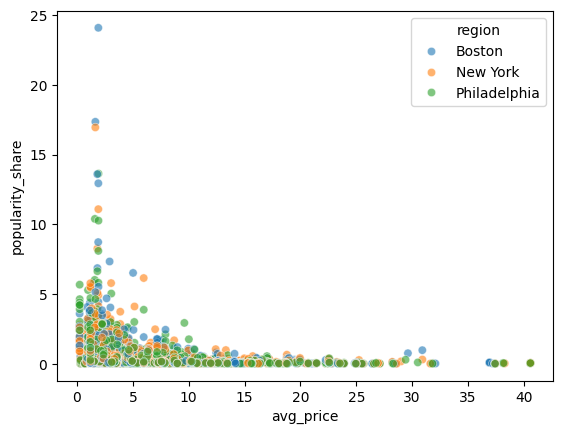

In [104]:
sns.scatterplot(
    data=item_state,
    x="avg_price",
    y="popularity_share",
    hue="region",
    alpha=0.6
)

In [105]:
price_pop_corr = (
    item_state
    .groupby("item")
    .apply(lambda x: x["avg_price"].corr(x["popularity_share"]))
    .rename("price_pop_corr")
    .reset_index()
)

In [106]:
price_pop_corr

,item,price_pop_corr
0,ACCESORIES_1_001,-0.90
1,ACCESORIES_1_002,0.61
2,ACCESORIES_1_003,1.00
3,ACCESORIES_1_004,0.29
4,ACCESORIES_1_005,-0.08
...,...,...
3044,SUPERMARKET_3_823,0.35
3045,SUPERMARKET_3_824,0.80
3046,SUPERMARKET_3_825,-0.94
3047,SUPERMARKET_3_826,0.86


In [107]:
item_support = (
    item_state
    .groupby("item")
    .agg(
        n_states=("region", "nunique"),
        price_std=("avg_price", "std"),
        pop_std=("popularity_share", "std")
    )
    .reset_index()
)

In [108]:
price_pop_corr = price_pop_corr.merge(
    item_support, on="item", how="left"
)

In [109]:
q_low = price_pop_corr["price_pop_corr"].quantile(0.25)
q_high = price_pop_corr["price_pop_corr"].quantile(0.75)

In [110]:
def price_segment(x):
    if pd.isna(x):
        return "insufficient_data"
    elif x >= q_high:
        return "premium"
    elif x <= q_low:
        return "price_sensitive"
    else:
        return "neutral"

price_pop_corr["price_segment"] = (
    price_pop_corr["price_pop_corr"].apply(price_segment)
)

In [111]:
item_popularity = (
    item_state
    .groupby("item")["total_sales"]
    .sum()
    .rename("total_sales")
)

price_pop_corr = price_pop_corr.merge(
    item_popularity, on="item"
)

In [112]:
sales_threshold = price_pop_corr["total_sales"].quantile(0.6)

best_items = price_pop_corr[
    (price_pop_corr["total_sales"] >= sales_threshold) &
    (price_pop_corr["price_segment"].isin(["premium", "price_sensitive"]))
]

In [113]:
best_items.sort_values("pop_std", ascending = False).head(10)

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2450,SUPERMARKET_3_226,-0.96,3,0.00,6.43,price_sensitive,363082
2476,SUPERMARKET_3_252,-0.94,3,0.00,4.85,price_sensitive,565299
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2918,SUPERMARKET_3_694,-1.00,3,0.00,3.49,price_sensitive,390001
2542,SUPERMARKET_3_318,0.86,3,0.01,1.90,premium,260598
2659,SUPERMARKET_3_435,0.94,3,0.01,1.80,premium,99356
2426,SUPERMARKET_3_202,-0.90,3,0.07,1.80,price_sensitive,295689
1706,SUPERMARKET_1_096,0.94,3,1.31,1.36,premium,92357
2267,SUPERMARKET_3_042,0.67,3,0.01,1.31,premium,92924
2007,SUPERMARKET_2_181,-0.87,3,0.09,1.23,price_sensitive,138531


In [114]:
best_items.sort_values("price_pop_corr", ascending = False).head()

,item,price_pop_corr,n_states,price_std,pop_std,price_segment,total_sales
2314,SUPERMARKET_3_090,1.00,3,0.02,3.91,premium,1002529
2733,SUPERMARKET_3_509,1.00,3,0.02,0.10,premium,18706
918,HOME_&_GARDEN_1_361,1.00,3,0.00,0.11,premium,27028
415,ACCESORIES_1_424,1.00,3,0.08,0.04,premium,15307
2386,SUPERMARKET_3_162,1.00,3,0.08,0.08,premium,17941


## Clustering

## TS 3: Feature Engineering --> añadir columnas

- Comprobar la correlación de la venta de un item dentro de una categoría, así como la venta de una categoría dentro de una tienda o región
- Jugar con correlaciones con ventas entre region, shop, category e item, entre ellas a pares

Revision de las tiendas que más han crecido y las que menos

Ventas por año en vez de totales? Productos más longevos tendrán más ventas

Ventas de productos pero que tengan ventas en el último año

serie temporal por item y store: en prophet
o xgboost

Comparación: métricas --> desvío en %, para tener en cuenta variación de magnitud de ventas --> más explicativo



Clustering:
Modelo de clustering: segmentación --> modelo no supervisado --> le pasamos una k con grupos de parámetros --> búsqueda de grupos similares para comprimir los 8000 items en pocos grupos
Estratégia del codo --> kmeans --> monta centroides en el espacio, se mueven los centroides para acercarse a los puntos --> la entropía se reduce con la cantidad de grupos, hay que encontrar el sweet spot (por lo general 5-6 grupos, si muchos no es fácil explicar)


In [115]:
df_dsMarket = df_dsMarket.reset_index(drop=True)

In [116]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 18 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        category      
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  category      
 6   region      category      
 7   day         object        
 8   sales       int32         
 9   date        datetime64[ns]
 10  yearweek    int32         
 11  start_date  datetime64[ns]
 12  event       category      
 13  is_Ramadan  int64         
 14  sell_price  float32       
 15  store_id    object        
 16  is_Event    bool          
 17  revenue     float64       
dtypes: bool(1), category(8), datetime64[ns](2), float32(1), float64(1), int32(2), int64(1), object(2)
memory usage: 3.0+ GB


In [117]:
df_dsMarket

,id,item,category,department,store,store_code,region,day,sales,date,yearweek,start_date,event,is_Ramadan,sell_price,store_id,is_Event,revenue
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,0.00
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,12.74
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,201328,2013-07-13,NoEvent,1,12.74,BOS_1_ACCESORIES_1,False,38.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46027952,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1909,0,2016-04-20,201616,2014-03-01,NoEvent,0,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027953,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1910,0,2016-04-21,201616,2014-03-01,NoEvent,0,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027954,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1911,0,2016-04-22,201616,2014-03-01,NoEvent,0,1.20,PHI_3_SUPERMARKET_3,False,0.00
46027955,SUPERMARKET_3_827_PHI_3,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1912,0,2016-04-23,201617,2014-03-01,NoEvent,0,1.20,PHI_3_SUPERMARKET_3,False,0.00


In [118]:
df_dsMarket.loc[df_dsMarket['start_date'] < '2011-02-01']

,id,item,category,department,store,store_code,region,day,sales,date,yearweek,start_date,event,is_Ramadan,sell_price,store_id,is_Event,revenue
36250,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,1,2011-01-29,201105,2011-01-29,NoEvent,0,5.77,BOS_1_ACCESORIES_1,False,5.77
36251,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,2,2011-01-30,201105,2011-01-29,NoEvent,0,5.77,BOS_1_ACCESORIES_1,False,11.54
36252,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,1,2011-01-31,201105,2011-01-29,NoEvent,0,5.77,BOS_1_ACCESORIES_1,False,5.77
36253,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,2011-02-01,201105,2011-01-29,NoEvent,0,5.77,BOS_1_ACCESORIES_1,False,0.00
36254,ACCESORIES_1_004_BOS_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,2,2011-02-02,201105,2011-01-29,NoEvent,0,5.77,BOS_1_ACCESORIES_1,False,11.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46010251,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1909,1,2016-04-20,201616,2011-01-29,NoEvent,0,4.78,PHI_3_SUPERMARKET_3,False,4.78
46010252,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1910,0,2016-04-21,201616,2011-01-29,NoEvent,0,4.78,PHI_3_SUPERMARKET_3,False,0.00
46010253,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1911,0,2016-04-22,201616,2011-01-29,NoEvent,0,4.78,PHI_3_SUPERMARKET_3,False,0.00
46010254,SUPERMARKET_3_825_PHI_3,SUPERMARKET_3_825,SUPERMARKET,SUPERMARKET_3,Queen_Village,PHI_3,Philadelphia,d_1912,1,2016-04-23,201617,2011-01-29,NoEvent,0,4.78,PHI_3_SUPERMARKET_3,False,4.78


## 5. Predicción Prophet

### Funcion forecasting

In [119]:
def plot_item_forecast(item_name):
    
    df_item = (
        df_dsMarket[df_dsMarket['item'] == item_name]
        .groupby('date', as_index=False)
        .agg({
            'sales': 'sum',
            'sell_price': 'mean',   # or weighted if you want later
            'is_Event': 'max',
            'is_Ramadan': 'max',
            'event': 'first'
        })
    )
#------- SPLIT TRAIN TEST -------    
    df_item = df_item.sort_values('date')

    #for logistic growth, we need to set a floor and cap
    df_item['floor'] = 0
    df_item['cap'] = df_item['sales'].max()

    split_date = df_item['date'].quantile(0.8)  # 80% train

    train = df_item[df_item['date'] <= split_date]
    test  = df_item[df_item['date'] > split_date]

#------- TRAIN TEST for PROPHET ------- 
    train_prophet = train[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})
    test_prophet = test[['date','sales','sell_price','is_Ramadan']]\
        .rename(columns={'date':'ds','sales':'y'})

#------- HOLIDAYS ------- 
    holidays = (
        df_item[df_item['event'] != 'NoEvent'][['date', 'event']]
        .drop_duplicates()
        .rename(columns={'date': 'ds', 'event': 'holiday'})
    )
    holidays['lower_window'] = -2   # 2 days before
    holidays['upper_window'] = 1    # 1 days after

#------- MODEL -------
    model = Prophet(
        holidays=holidays,
        seasonality_mode='multiplicative',
        #growth='logistic',
        yearly_seasonality=True,
        daily_seasonality=False
    )

    model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.1) # the less the better, but it already has limitations

    model.add_regressor('sell_price')
    model.add_regressor('is_Ramadan')

    model.fit(train_prophet)

#------- FORECAST -------
    future = test_prophet[['ds', 'sell_price', 'is_Ramadan']]\
        .rename(columns = {'date':'ds'})
    forecast = model.predict(future)
    
#------- MAE ------- 
    print(len(test)+ len(train))
    forecast_test = forecast.set_index('ds').loc[test['date']]

    mae = mean_absolute_error(test['sales'], forecast_test['yhat'])

    print("MAE:", mae)

#------- PLOT ------- 
    fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

    # --- Top plot: Train + Test + Forecast ---
    axes[0].plot(test['date'], test['sales'], label='Test')
    axes[0].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[0].plot(train['date'], train['sales'], label='Train', color='gray', alpha=0.5)
    axes[0].set_title('Prophet Forecast vs Actuals')
    axes[0].legend()

    # --- Bottom plot: Test + Forecast only ---
    axes[1].plot(test['date'], test['sales'], label='Test')
    axes[1].plot(forecast['ds'], forecast['yhat'], label='Forecast')
    axes[1].set_title('Test vs Forecast (Zoom)')
    axes[1].legend()
    axes[1].fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

    return forecast


22:28:23 - cmdstanpy - INFO - Chain [1] start processing
22:28:23 - cmdstanpy - INFO - Chain [1] done processing


1122
MAE: 4.210287499458076


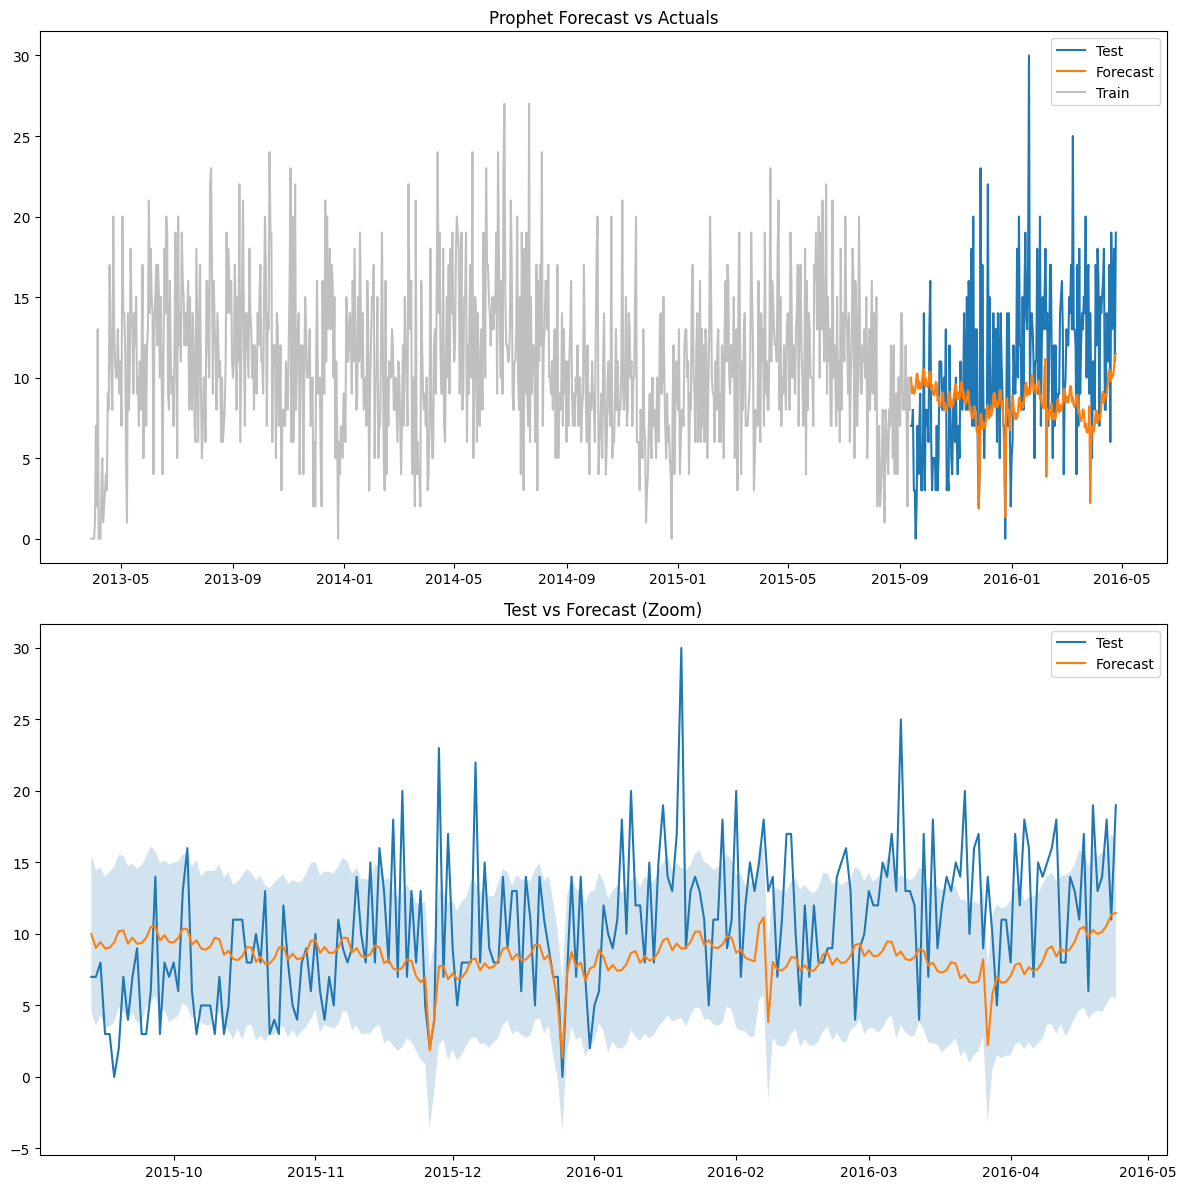

In [120]:
prophet_forecast = plot_item_forecast('SUPERMARKET_3_826')

## 6. Algoritmo XGBoost

In [121]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
TARGET = "sales"
GROUP_COLS = ["store_code", "item"]
DATE_COL = "date"                        # raw date column (will be dropped after extraction)
 
# Columns to DROP entirely (pure identifiers / redundant)
DROP_COLS = ['id', 'day', 'store', "store_id", 'start_date', 'yearweek', 'revenue']         
 
# Categorical columns to ENCODE
CAT_COLS = ["item", "category", "department", "store_code", "region", "event"]
 
# Lag distances (in days)
LAG_DAYS = [1, 7, 14, 28]
 
# Rolling window sizes (in days)
ROLL_WINDOWS = [7, 14, 28]
 
TRAIN_RATIO = 0.8

In [122]:
# ─────────────────────────────────────────────
# 2. DROP REDUNDANT COLUMNS
# ─────────────────────────────────────────────
def drop_redundant(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=existing)
    print(f"Dropped redundant columns: {existing}")
    return df

In [123]:
df_dsMarket_dropped_cols = drop_redundant(df_dsMarket)

Dropped redundant columns: ['id', 'day', 'store', 'store_id', 'start_date', 'yearweek', 'revenue']


In [124]:
# ─────────────────────────────────────────────
# 3. EXTRACT DATE FEATURES  →  DROP RAW DATE
# ─────────────────────────────────────────────
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df[DATE_COL]
    df["day_of_week"]   = d.dt.dayofweek          # 0=Mon … 6=Sun
    df["day_of_month"]  = d.dt.day
    df["week_of_year"]  = d.dt.isocalendar().week.astype(int)
    df["month"]         = d.dt.month
    df["quarter"]       = d.dt.quarter
    df["is_weekend"]    = (d.dt.dayofweek >= 5).astype(int)
    df["year"]          = d.dt.year
    df = df.drop(columns=[DATE_COL])
    print("Added date features and dropped raw date column.")
    return df

In [125]:
# ─────────────────────────────────────────────
# 4. ENCODE CATEGORICALS
# ─────────────────────────────────────────────
def encode_categoricals(df: pd.DataFrame) -> tuple[pd.DataFrame, OrdinalEncoder]:
    existing_cats = [c for c in CAT_COLS if c in df.columns]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    df[existing_cats] = enc.fit_transform(df[existing_cats]).astype(int)
    print(f"Encoded categoricals: {existing_cats}")
    return df, enc

In [126]:
# ─────────────────────────────────────────────
# 5. LAG FEATURES  (per store_code × item_id)
# ─────────────────────────────────────────────
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    # NOTE: df must still be sorted by [date-equivalent cols] + GROUP_COLS at this point.
    # Since we dropped the date column we rely on the sort done at load time.
    grp = df.groupby(GROUP_COLS)[TARGET]
    for lag in LAG_DAYS:
        df[f"lag_{lag}"] = grp.shift(lag)
    print(f"Added lag features: {[f'lag_{l}' for l in LAG_DAYS]}")
    return df

In [127]:
# ─────────────────────────────────────────────
# 6. ROLLING FEATURES  (per store_code × item_id)
# ─────────────────────────────────────────────
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.groupby(GROUP_COLS)[TARGET]
    for w in ROLL_WINDOWS:
        # shift(1) prevents leakage: window ends the day BEFORE the current row
        rolled = grp.shift(1).groupby(df[GROUP_COLS[0]])   # re-group after shift
        # Simpler: use transform with shift inside
        shifted = grp.shift(1)
        df[f"roll_mean_{w}"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
        df[f"roll_std_{w}"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        )
    print(f"Added rolling mean/std features for windows: {ROLL_WINDOWS}")
    return df

In [128]:
# ─────────────────────────────────────────────
# 7. DROP NaN ROWS FROM LAG/ROLLING
# ─────────────────────────────────────────────
def drop_nan_rows(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"Dropped {before - len(df):,} NaN rows (from lag/rolling warmup). Remaining: {len(df):,}")
    return df

In [129]:
# ─────────────────────────────────────────────
# 8. TEMPORAL TRAIN / TEST SPLIT  (no shuffle)
# ─────────────────────────────────────────────
def temporal_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_idx = int(len(df) * TRAIN_RATIO)
    train, test = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()
    print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")
    return train, test

In [130]:
# ─────────────────────────────────────────────
# 9. FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────
def split_X_y(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    return X, y

In [131]:
# ─────────────────────────────────────────────
# EVALUATION HELPER
# ─────────────────────────────────────────────
def evaluate(y_true, y_pred, name: str):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    # Zero-sale accuracy: % of days where both actual and predicted are 0
    zero_acc = np.mean((y_true == 0) & (y_pred < 0.5)) / max(np.mean(y_true == 0), 1e-9)
    print(f"{name:12s} | MAE: {mae:.4f}  RMSE: {rmse:.4f}  Zero-accuracy: {zero_acc:.2%}")

In [132]:
# ─────────────────────────────────────────────
# 10a. TRAIN — XGBOOST
# ─────────────────────────────────────────────
def train_xgboost(X_train, y_train, X_test, y_test):
    print("\n── XGBoost ──")
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",       # fast histogram method
        early_stopping_rounds=30,
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100,
    )
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)   # clip negatives — demand can't be < 0
    evaluate(y_test, preds, "XGBoost")
    return model, preds

In [133]:
# ─────────────────────────────────────────────
# 10b. TRAIN — LIGHTGBM
# ─────────────────────────────────────────────
def train_lightgbm(X_train, y_train, X_test, y_test):
    print("\n── LightGBM ──")
 
    # LightGBM can use native categoricals — re-cast them
    cat_features = [c for c in CAT_COLS if c in X_train.columns]
    X_train_lgb = X_train.copy()
    X_test_lgb  = X_test.copy()
    for col in cat_features:
        X_train_lgb[col] = X_train_lgb[col].astype("category")
        X_test_lgb[col]  = X_test_lgb[col].astype("category")
 
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(
        X_train_lgb, y_train,
        eval_set=[(X_test_lgb, y_test)],
        categorical_feature=cat_features,
        callbacks=[lgb.log_evaluation(100)],
    )
    preds = model.predict(X_test_lgb)
    preds = np.maximum(preds, 0)
    evaluate(y_test, preds, "LightGBM")
    return model, preds

In [134]:
# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────
def run_pipeline(df: pd.DataFrame) -> dict:
    #df = load_data(data_path)
    df = drop_redundant(df)
    df = add_date_features(df)
    df, encoder = encode_categoricals(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = drop_nan_rows(df)
 
    train_df, test_df = temporal_split(df)
    X_train, y_train = split_X_y(train_df)
    X_test,  y_test  = split_X_y(test_df)
 
    print(f"\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}\n")
 
    xgb_model, xgb_preds = train_xgboost(X_train, y_train, X_test, y_test)
    lgb_model, lgb_preds = train_lightgbm(X_train, y_train, X_test, y_test)
 
    return {
        "xgb": xgb_model,
        "lgb": lgb_model,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "xgb_preds": xgb_preds,
        "lgb_preds": lgb_preds,
    }
 
 
if __name__ == "__main__":
    # Replace with your actual file path
    daily_results = run_pipeline(df_dsMarket)

Dropped redundant columns: ['id', 'day', 'store', 'store_id', 'start_date', 'yearweek', 'revenue']
Added date features and dropped raw date column.
Encoded categoricals: ['item', 'category', 'department', 'store_code', 'region', 'event']
Added lag features: ['lag_1', 'lag_7', 'lag_14', 'lag_28']
Added rolling mean/std features for windows: [7, 14, 28]
Dropped 853,720 NaN rows (from lag/rolling warmup). Remaining: 45,174,237
Train: 36,139,389 rows | Test: 9,034,848 rows

Features (26): ['item', 'category', 'department', 'store_code', 'region', 'event', 'is_Ramadan', 'sell_price', 'is_Event', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter', 'is_weekend', 'year', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']


── XGBoost ──
[0]	validation_0-mae:2.59912
[100]	validation_0-mae:1.54918
[101]	validation_0-mae:1.54903
XGBoost      | MAE: 1.5466  RMSE: 3.7375  Zero-accuracy: 52.98%

── LightGBM 

In [135]:
# ── consistent style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e8e8e8",
    "grid.linewidth":   0.6,
    "font.size":        11,
})
 
XGB_COLOR = "#E8593C"   # coral
LGB_COLOR = "#185FA5"   # blue
ACT_COLOR = "#444441"   # dark gray

In [136]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. HOW TO ATTACH test_meta  (helper — run once after pipeline)
# ══════════════════════════════════════════════════════════════════════════════
 
def build_test_meta(original_df: pd.DataFrame, test_index: pd.Index) -> pd.DataFrame:
    """
    Reconstruct the test-set metadata (original group columns + date) from
    the raw DataFrame, aligned to the test split index.
 
    Call this BEFORE running add_date_features() drops the date column,
    or keep a separate copy of the raw df.
 
    Parameters
    ----------
    original_df : the raw DataFrame as loaded (with 'date', 'store_code',
                  'item_id', 'category', 'department', 'store', 'region')
    test_index  : results["X_test"].index  (the integer positions of test rows
                  in the post-lag-drop DataFrame — see note below)
 
    NOTE: Because drop_nan_rows() resets the index, the cleanest approach is:
        1. Save original_df before any processing.
        2. After run_pipeline(), note that test rows come from the LAST 20%
           of the processed df. Re-apply the same sort + dropna to original_df,
           then take the last 20% slice.
 
    Example
    -------
        raw = pd.read_csv("your_data.csv", parse_dates=["date"])
        raw = raw.sort_values(["date", "store_code", "item_id"]).reset_index(drop=True)
        results = run_pipeline("your_data.csv")
 
        # Reproduce the row count after lag warmup drop (≈ original minus 28 rows per group)
        split_idx = int(len(results["X_test"]) / 0.2 * 0.8)
        # safer: just use X_test.index if you preserved indices in the pipeline
        test_meta = build_test_meta(raw, results["X_test"].index)
    """
    meta_cols = ["date", "store_code", "item", "category", "department"]
    available = [c for c in meta_cols if c in original_df.columns]
    return original_df.loc[test_index, available].reset_index(drop=True)

In [137]:
train_meta = build_test_meta(df_dsMarket, daily_results["X_train"].index)

In [138]:
test_meta  = build_test_meta(df_dsMarket, daily_results["X_test"].index)

In [139]:
daily_results["X_test"].describe()

,item,category,department,store_code,region,event,is_Ramadan,sell_price,day_of_week,day_of_month,week_of_year,month,quarter,is_weekend,year,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28
count,"9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00","9,034,848.00"
mean,"2,741.57",2.00,6.00,4.48,0.99,3.99,0.08,3.38,3.00,15.72,26.24,6.43,2.48,0.29,"2,013.58",2.72,2.72,2.72,2.73,2.72,1.76,2.72,1.89,2.72,2.01
std,177.14,0.00,0.00,2.88,0.77,0.35,0.27,2.04,2.00,8.79,15.20,3.47,1.13,0.45,1.46,6.71,6.72,6.72,6.75,5.96,2.82,5.84,2.86,5.74,2.95
min,"2,438.00",2.00,6.00,0.00,0.00,0.00,0.00,0.01,0.00,1.00,1.00,1.00,1.00,0.00,"2,011.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"2,588.00",2.00,6.00,2.00,0.00,4.00,0.00,2.14,1.00,8.00,13.00,3.00,1.00,0.00,"2,012.00",0.00,0.00,0.00,0.00,0.29,0.49,0.36,0.61,0.39,0.69
50%,"2,738.00",2.00,6.00,4.00,1.00,4.00,0.00,3.00,3.00,16.00,26.00,6.00,2.00,0.00,"2,014.00",1.00,1.00,1.00,1.00,1.00,1.07,1.00,1.16,1.07,1.24
75%,"2,895.00",2.00,6.00,7.00,2.00,4.00,0.00,4.20,5.00,23.00,40.00,9.00,3.00,1.00,"2,015.00",3.00,3.00,3.00,3.00,2.57,2.04,2.64,2.13,2.61,2.23
max,"3,048.00",2.00,6.00,9.00,2.00,7.00,1.00,23.38,6.00,31.00,53.00,12.00,4.00,1.00,"2,016.00",648.00,648.00,648.00,648.00,221.43,241.59,170.86,170.74,140.36,167.39


In [140]:
test_meta

,date,store_code,item,category,department
0,2013-05-07,BOS_2,SUPERMARKET_3_169,SUPERMARKET,SUPERMARKET_3
1,2013-05-08,BOS_2,SUPERMARKET_3_169,SUPERMARKET,SUPERMARKET_3
2,2013-05-09,BOS_2,SUPERMARKET_3_169,SUPERMARKET,SUPERMARKET_3
3,2013-05-10,BOS_2,SUPERMARKET_3_169,SUPERMARKET,SUPERMARKET_3
4,2013-05-11,BOS_2,SUPERMARKET_3_169,SUPERMARKET,SUPERMARKET_3
...,...,...,...,...,...
9034843,2012-12-19,BOS_3,SUPERMARKET_3_771,SUPERMARKET,SUPERMARKET_3
9034844,2012-12-20,BOS_3,SUPERMARKET_3_771,SUPERMARKET,SUPERMARKET_3
9034845,2012-12-21,BOS_3,SUPERMARKET_3_771,SUPERMARKET,SUPERMARKET_3
9034846,2012-12-22,BOS_3,SUPERMARKET_3_771,SUPERMARKET,SUPERMARKET_3


In [141]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════
def _hint_importance(xgb_imp, lgb_imp):
    top_xgb = xgb_imp.index[-1]
    top_lgb = lgb_imp.index[-1]
    print(f"\n💡 Top feature XGBoost: '{top_xgb}' | LightGBM: '{top_lgb}'")
    lag_features  = [f for f in xgb_imp.index if "lag"  in f]
    roll_features = [f for f in xgb_imp.index if "roll" in f]
    if lag_features:
        print(f"   Lag features present in top-{len(xgb_imp)}: {lag_features}")
    if roll_features:
        print(f"   Rolling features present: {roll_features}")


def plot_feature_importance(xgb_model, lgb_model, X_test: pd.DataFrame, top_n: int = 20):
    """
    Side-by-side horizontal bar charts of feature importances.
    XGBoost uses gain; LightGBM uses split count (default).
 
    Parameters
    ----------
    xgb_model  : trained XGBRegressor
    lgb_model  : trained LGBMRegressor
    X_test     : feature DataFrame (used to get column names)
    top_n      : how many features to show
    """
    feat_names = X_test.columns.tolist()
 
    def _normalize(series: pd.Series) -> pd.Series:
        """Normalize raw importances to 0–100 scale."""
        total = series.sum()
        if total == 0:
            return series
        return (series / total * 100)
 
    # XGBoost — use get_booster().get_score(importance_type="gain") to avoid
    # the float-precision issue with .feature_importances_ returning near-zero values
    xgb_raw_scores = xgb_model.get_booster().get_score(importance_type="gain")
    xgb_raw = pd.Series(xgb_raw_scores).reindex(feat_names).fillna(0)
    xgb_imp = _normalize(xgb_raw).sort_values(ascending=True).tail(top_n)
 
    # LightGBM — gain importance normalized to 0-100
    lgb_raw = pd.Series(lgb_model.feature_importances_, index=feat_names)
    lgb_imp = _normalize(lgb_raw).sort_values(ascending=True).tail(top_n)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, top_n * 0.35)))
 
    for ax, imp, color, title in [
        (axes[0], xgb_imp, XGB_COLOR, "XGBoost — feature importance (%)"),
        (axes[1], lgb_imp, LGB_COLOR, "LightGBM — feature importance (%)"),
    ]:
        bars = ax.barh(imp.index, imp.values, color=color, alpha=0.85, height=0.65)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
        ax.set_xlabel("Importance score")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        # label the bars
        for bar in bars:
            w = bar.get_width()
            ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
                    f"{w:,.0f}", va="center", fontsize=9, color="#444")
 
    fig.suptitle("Feature importance — top features", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → feature_importance.png")
 
    # Print interpretation hint
    _hint_importance(xgb_imp, lgb_imp)

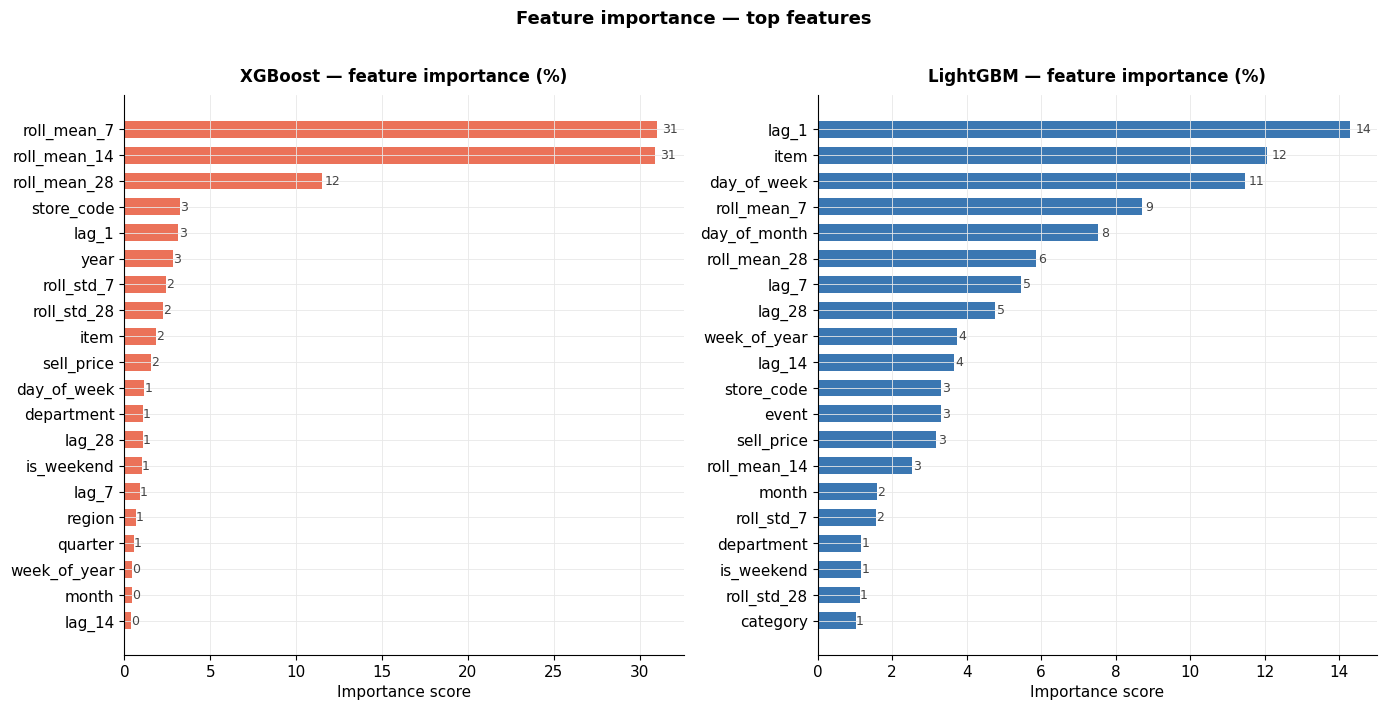

Saved → feature_importance.png

💡 Top feature XGBoost: 'roll_mean_7' | LightGBM: 'lag_1'
   Lag features present in top-20: ['lag_14', 'lag_7', 'lag_28', 'lag_1']
   Rolling features present: ['roll_std_28', 'roll_std_7', 'roll_mean_28', 'roll_mean_14', 'roll_mean_7']


In [142]:
# ── 1. Feature importance ─────────────────────────────────────────────────
plot_feature_importance(daily_results["xgb"], daily_results["lgb"], daily_results["X_test"], top_n=20)

In [143]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. PER-GROUP ERROR BREAKDOWN
# ══════════════════════════════════════════════════════════════════════════════
 
def _rmsse(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray) -> float:
    """
    Root Mean Squared Scaled Error (M5 competition metric).
    Scales RMSE by the naive in-sample lag-1 forecast error.
    Values < 1 mean the model beats a simple lag-1 baseline.
    Robust to zeros — ideal for intermittent demand.
 
    y_train : the TRAINING sales values for this group (used to compute naive error).
    """
    naive_errors = np.diff(y_train)          # y[t] - y[t-1] for all training steps
    naive_mse    = np.mean(naive_errors ** 2)
    if naive_mse == 0:
        return np.nan
    mse = np.mean((y_true - y_pred) ** 2)
    return float(np.sqrt(mse / naive_mse))
 
 
def compute_group_errors(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str,
    train_meta: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Compute MAE, NMAE (by mean), RMSSE and zero-accuracy per group.
 
    Normalized metrics
    ------------------
    NMAE  = MAE / mean(y_true)   — "error as % of average demand"
            Intuitive for stakeholders; breaks only when mean=0 (fully dead items).
    RMSSE = sqrt(MSE / naive_MSE) — M5 Walmart competition standard.
            < 1.0  → beats a simple lag-1 naive forecast (good)
            > 1.0  → worse than just repeating yesterday (bad)
            Requires train_meta to compute the naive in-sample error.
 
    Parameters
    ----------
    results    : dict returned by run_pipeline()
    test_meta  : DataFrame aligned to results["X_test"] with group cols + sales
    group_col  : 'category', 'department', 'store_code', 'item_id', etc.
    train_meta : same structure as test_meta but for training rows — needed for
                 RMSSE. If None, RMSSE columns are omitted.
    """
    y_true   = results["y_test"].values
    xgb_pred = results["xgb_preds"]
    lgb_pred = results["lgb_preds"]
    groups   = test_meta[group_col].values
 
    has_train = train_meta is not None
 
    rows = []
    for grp in sorted(set(groups)):
        mask = groups == grp
        yt = y_true[mask]
        if len(yt) == 0:
            continue
        xp = xgb_pred[mask]
        lp = lgb_pred[mask]
 
        mean_y    = float(yt.mean())
        zero_frac = float(np.mean(yt == 0))
        denom     = max(mean_y, 1e-9)         # avoid /0 on dead items
 
        row = {
            group_col:           grp,
            "n_rows":            int(mask.sum()),
            "mean_sales":        round(mean_y, 3),
            "zero_fraction":     round(zero_frac, 3),
            # ── raw ──────────────────────────────────────────────────────────
            "xgb_mae":           round(mean_absolute_error(yt, xp), 4),
            "lgb_mae":           round(mean_absolute_error(yt, lp), 4),
            # ── NMAE: error as % of mean demand ──────────────────────────────
            "xgb_nmae":          round(mean_absolute_error(yt, xp) / denom, 4),
            "lgb_nmae":          round(mean_absolute_error(yt, lp) / denom, 4),
            # ── zero-accuracy ─────────────────────────────────────────────────
            "xgb_zero_acc":      round(np.mean((yt == 0) & (xp < 0.5)) / max(zero_frac, 1e-9), 4),
            "lgb_zero_acc":      round(np.mean((yt == 0) & (lp < 0.5)) / max(zero_frac, 1e-9), 4),
        }
 
        # ── RMSSE (only if training data provided) ───────────────────────────
        if has_train:
            train_mask = train_meta[group_col].values == grp
            yt_train   = results["y_train"].values[train_mask] if "y_train" in results \
                         else train_meta.loc[train_mask, TARGET].values
            row["xgb_rmsse"] = round(_rmsse(yt, xp, yt_train), 4)
            row["lgb_rmsse"] = round(_rmsse(yt, lp, yt_train), 4)
 
        rows.append(row)
 
    return pd.DataFrame(rows).sort_values("xgb_nmae", ascending=False).reset_index(drop=True)
 
 
def plot_group_errors(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str = "category",
    train_meta: pd.DataFrame | None = None,
):
    """
    3-panel chart per group: NMAE (normalized MAE), Zero-accuracy, and
    optionally RMSSE when train_meta is provided.
 
    NMAE  : MAE / mean(sales) — read as "error as % of average demand"
    RMSSE : < 1.0 beats naive lag-1 baseline; > 1.0 is worse than naive.
    """
    df_err = compute_group_errors(results, test_meta, group_col, train_meta)
    print(f"\n── Per-{group_col} breakdown ──")
    print(df_err.to_string(index=False))
 
    has_rmsse = "xgb_rmsse" in df_err.columns
    n_panels  = 3 if has_rmsse else 2
    n_groups  = len(df_err)
    x = np.arange(n_groups)
    w = 0.35
 
    fig, axes = plt.subplots(1, n_panels, figsize=(max(5 * n_panels, n_groups * 1.4 * n_panels), 5))
 
    # ── Panel 1: NMAE ─────────────────────────────────────────────────────────
    ax = axes[0]
    ax.bar(x - w/2, df_err["xgb_nmae"] * 100, w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
    ax.bar(x + w/2, df_err["lgb_nmae"] * 100, w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df_err[group_col], rotation=30, ha="right")
    ax.set_ylabel("NMAE  (% of mean demand)")
    ax.set_title(f"Normalized MAE by {group_col}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend()
    # annotate mean_sales above bars
    for i, row in df_err.iterrows():
        top = max(row["xgb_nmae"], row["lgb_nmae"]) * 100
        ax.text(i, top + 0.5, f"μ={row['mean_sales']:.1f}", ha="center", fontsize=8, color="#666")
 
    # ── Panel 2: Zero-accuracy ────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.bar(x - w/2, df_err["xgb_zero_acc"], w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
    ax2.bar(x + w/2, df_err["lgb_zero_acc"], w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(df_err[group_col], rotation=30, ha="right")
    ax2.set_ylabel("Zero-accuracy (ratio)")
    ax2.set_title(f"Zero-accuracy by {group_col}", fontweight="bold")
    ax2.set_ylim(0, 1.15)
    ax2.axhline(1.0, color="#aaa", linewidth=0.8, linestyle="--")
    ax2.legend()
 
    # ── Panel 3: RMSSE (optional) ─────────────────────────────────────────────
    if has_rmsse:
        ax3 = axes[2]
        ax3.bar(x - w/2, df_err["xgb_rmsse"], w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
        ax3.bar(x + w/2, df_err["lgb_rmsse"], w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
        ax3.set_xticks(x); ax3.set_xticklabels(df_err[group_col], rotation=30, ha="right")
        ax3.set_ylabel("RMSSE")
        ax3.set_title(f"RMSSE by {group_col}\n(< 1.0 beats naive forecast)", fontweight="bold")
        ax3.axhline(1.0, color="#e03030", linewidth=1, linestyle="--", label="Naive baseline")
        ax3.legend()
 
    fig.suptitle(f"Model errors grouped by {group_col}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"errors_by_{group_col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")
 
    _hint_group_errors(df_err, group_col)
    return df_err
 
 
def _hint_group_errors(df: pd.DataFrame, group_col: str):
    worst = df.iloc[0][group_col]
    best  = df.iloc[-1][group_col]
    print(f"\n💡 Hardest group to predict ({group_col}): '{worst}' "
          f"(XGB MAE={df.iloc[0]['xgb_mae']:.3f})")
    print(f"   Easiest group: '{best}' "
          f"(XGB MAE={df.iloc[-1]['xgb_mae']:.3f})")
 
    high_zero = df[df["zero_fraction"] > 0.5]
    if not high_zero.empty:
        print(f"   Groups with >50% zero-sales days: "
              f"{high_zero[group_col].tolist()} — zero-accuracy is the key metric here.")
 


── Per-category breakdown ──
   category  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc  xgb_rmsse  lgb_rmsse
SUPERMARKET 9034848        2.72           0.47     1.55     1.51      0.57      0.56          0.53          0.54       1.17       1.07


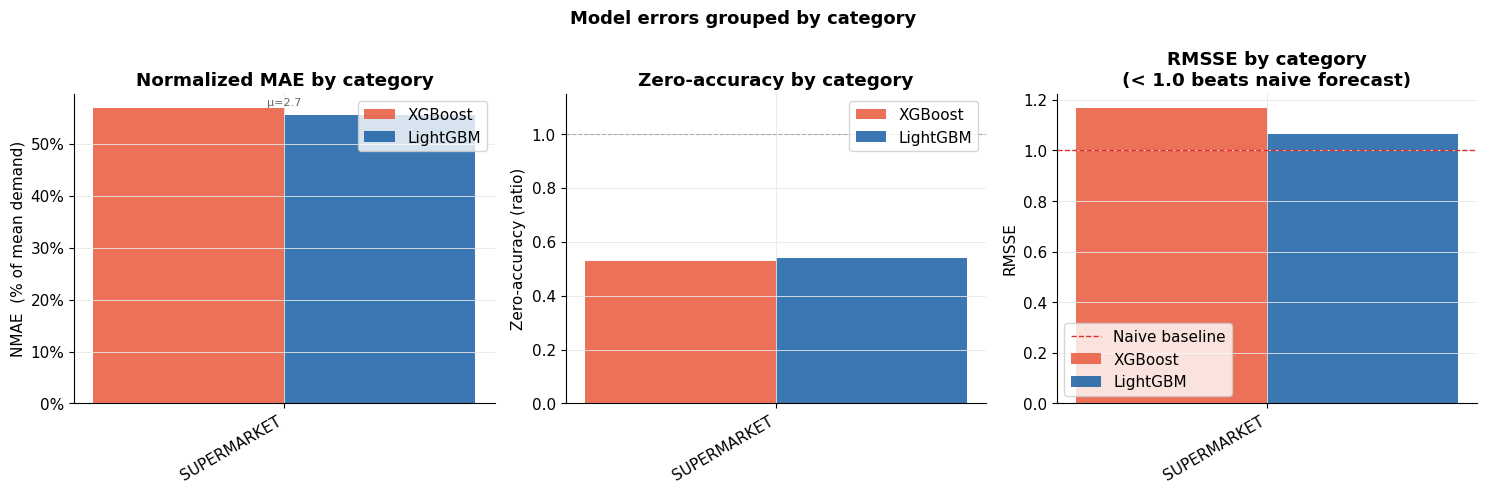

Saved → errors_by_category.png

💡 Hardest group to predict (category): 'SUPERMARKET' (XGB MAE=1.547)
   Easiest group: 'SUPERMARKET' (XGB MAE=1.547)

── Per-department breakdown ──
   department  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc  xgb_rmsse  lgb_rmsse
SUPERMARKET_3 9034848        2.72           0.47     1.55     1.51      0.57      0.56          0.53          0.54       0.80       0.73


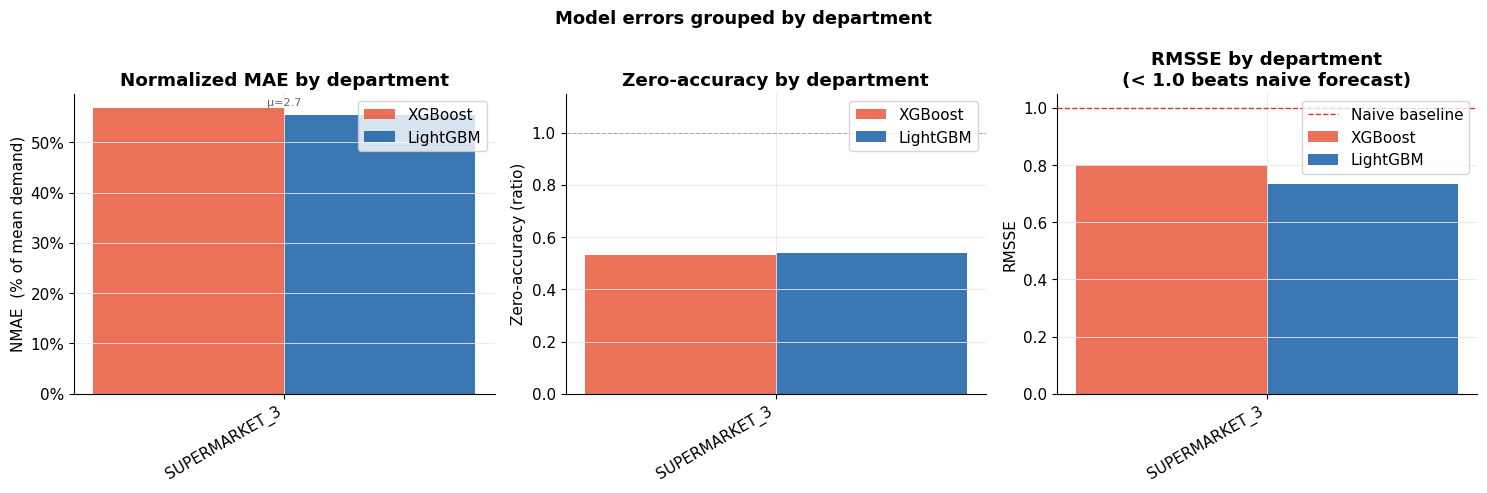

Saved → errors_by_department.png

💡 Hardest group to predict (department): 'SUPERMARKET_3' (XGB MAE=1.547)
   Easiest group: 'SUPERMARKET_3' (XGB MAE=1.547)

── Per-store_code breakdown ──
store_code  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc  xgb_rmsse  lgb_rmsse
     BOS_2  923489        2.56           0.47     1.50     1.47      0.58      0.58          0.53          0.54       1.37       1.30
     PHI_3  911296        2.66           0.47     1.55     1.50      0.58      0.56          0.53          0.54       1.37       1.20
     NYC_3  915776        2.53           0.47     1.46     1.44      0.58      0.57          0.54          0.55       1.27       1.22
     BOS_1  923525        2.62           0.47     1.50     1.48      0.57      0.57          0.52          0.53       1.28       1.25
     BOS_3  911207        2.87           0.47     1.64     1.60      0.57      0.56          0.52          0.53       1.72       1.59
     NY

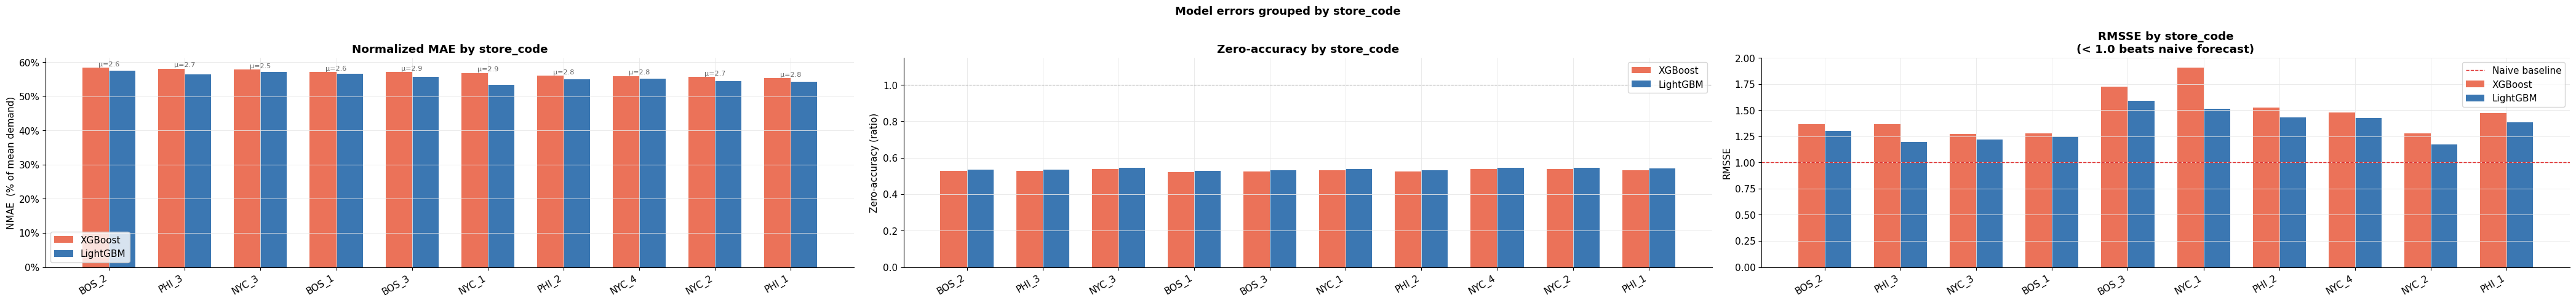

Saved → errors_by_store_code.png

💡 Hardest group to predict (store_code): 'BOS_2' (XGB MAE=1.498)
   Easiest group: 'PHI_1' (XGB MAE=1.542)


In [144]:
# ── 2. Per-group errors ───────────────────────────────────────────────────
for grp in ["category", "department", "store_code"]:
    plot_group_errors(daily_results, test_meta, group_col=grp, train_meta=train_meta)

In [145]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ACTUAL vs PREDICTED — single item/store
# ══════════════════════════════════════════════════════════════════════════════
 
def plot_item_prediction(
    results: dict,
    test_meta: pd.DataFrame,
    item: str,
    store_code: str | None = None,
    prophet_preds: np.ndarray | None = None,
    last_n_days: int | None = None,
):
    """
    Line chart: actual vs predicted sales for a given item.
 
    store_code=None  → aggregate (sum) across ALL stores for that item.
                       Useful when Prophet was trained on total demand.
    store_code='NYC_1' → single store × item view.
 
    prophet_preds : 1-D array aligned to the SAME mask/aggregation as the
                    tree model predictions. For all-store mode, pass the
                    Prophet forecast already summed across stores.
    last_n_days   : zoom into the final N periods only.
    """
    # ── build mask ────────────────────────────────────────────────────────────
    item_mask = test_meta["item"] == item
    if item_mask.sum() == 0:
        print(f"item '{item}' not found. Available: {sorted(test_meta['item'].unique())[:20]}")
        return
 
    all_stores = store_code is None
    if not all_stores:
        store_mask = test_meta["store_code"] == store_code
        mask = item_mask & store_mask
        if mask.sum() == 0:
            print(f"No rows for store_code='{store_code}', item='{item}'.")
            print(f"Available store_codes: {sorted(test_meta['store_code'].unique())}")
            return
        title_label = f"{store_code} | {item}"
    else:
        mask = item_mask
        title_label = f"ALL STORES | {item}"
 
    y_true   = results["y_test"].values[mask]
    xgb_pred = results["xgb_preds"][mask]
    lgb_pred = results["lgb_preds"][mask]
    dates_raw = (test_meta.loc[mask, "date"].values
                 if "date" in test_meta.columns else None)
 
    # ── aggregate across stores if needed ────────────────────────────────────
    if all_stores and dates_raw is not None:
        tmp = pd.DataFrame({
            "date":    dates_raw,
            "actual":  y_true,
            "xgb":     xgb_pred,
            "lgb":     lgb_pred,
        })
        # prophet: sum per date if provided as per-row array
        # if prophet_preds is not None:
        #     tmp["prophet"] = prophet_preds[mask] if len(prophet_preds) == len(mask) \
        #                      else prophet_preds   # already aggregated
        tmp = tmp.groupby("date").sum().reset_index()
        dates    = tmp["date"].values
        y_true   = tmp["actual"].values
        xgb_pred = tmp["xgb"].values
        lgb_pred = tmp["lgb"].values
        #prophet_preds = tmp["prophet"].values if "prophet" in tmp.columns else None
    else:
        dates = dates_raw if dates_raw is not None else np.arange(len(y_true))
 
    # ── optional zoom ─────────────────────────────────────────────────────────
    if last_n_days:
        dates    = dates[-last_n_days:]
        y_true   = y_true[-last_n_days:]
        xgb_pred = xgb_pred[-last_n_days:]
        lgb_pred = lgb_pred[-last_n_days:]
        if prophet_preds is not None:
            prophet_preds = prophet_preds[-last_n_days:]
 
    # ── compute metrics ───────────────────────────────────────────────────────
    mean_y   = max(float(y_true.mean()), 1e-9)
    xgb_mae  = mean_absolute_error(y_true, xgb_pred)
    lgb_mae  = mean_absolute_error(y_true, lgb_pred)
    xgb_nmae = xgb_mae / mean_y
    lgb_nmae = lgb_mae / mean_y
 
    info = (f"XGB  MAE={xgb_mae:.2f} ({xgb_nmae:.0%} of mean)  |  "
            f"LGB  MAE={lgb_mae:.2f} ({lgb_nmae:.0%} of mean)")
    if prophet_preds is not None:
        p_mae  = mean_absolute_error(y_true, prophet_preds)
        p_nmae = p_mae / mean_y
        info  += f"  |  Prophet MAE={p_mae:.2f} ({p_nmae:.0%})"
 
    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(dates, y_true, alpha=0.10, color=ACT_COLOR)
    ax.plot(dates, y_true,   color=ACT_COLOR, linewidth=1.8, label="Actual",   zorder=4)
    ax.plot(dates, xgb_pred, color=XGB_COLOR, linewidth=1.2, label="XGBoost",  zorder=3, alpha=0.9)
    ax.plot(dates, lgb_pred, color=LGB_COLOR, linewidth=1.2, label="LightGBM", zorder=3,
            alpha=0.9, linestyle="--")
 
    if prophet_preds is not None:
        ax.plot(dates, prophet_preds, color="#1D9E75", linewidth=1.2,
                label="Prophet", zorder=2, alpha=0.85, linestyle=":")
 
    ax.set_title(f"{title_label} — test set\n{info}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Sales (summed)" if all_stores else "Sales")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
 
    fname = f"pred_{'ALL' if all_stores else store_code}_{item}.png".replace("/", "-")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

In [146]:
# # ── 3. Single item deep-dive (replace with your actual IDs) ──────────────
plot_item_prediction(
    daily_results, test_meta,
    store_code=None,   # set to None to aggregate across all stores for this item
    item="SUPERMARKET_3_826",
    prophet_preds=prophet_forecast["yhat"],   # pass your Prophet prediction array here to compare
    last_n_days=90,
)

item 'SUPERMARKET_3_826' not found. Available: ['SUPERMARKET_3_169', 'SUPERMARKET_3_170', 'SUPERMARKET_3_171', 'SUPERMARKET_3_172', 'SUPERMARKET_3_173', 'SUPERMARKET_3_174', 'SUPERMARKET_3_175', 'SUPERMARKET_3_176', 'SUPERMARKET_3_177', 'SUPERMARKET_3_178', 'SUPERMARKET_3_179', 'SUPERMARKET_3_180', 'SUPERMARKET_3_181', 'SUPERMARKET_3_182', 'SUPERMARKET_3_183', 'SUPERMARKET_3_184', 'SUPERMARKET_3_185', 'SUPERMARKET_3_186', 'SUPERMARKET_3_187', 'SUPERMARKET_3_188']


In [173]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. MULTI-GROUP GRID  (quick overview across all groups at once)
# ══════════════════════════════════════════════════════════════════════════════
 
def plot_group_predictions_grid(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str = "category",
    last_n_days: int = 90,
):
    """
    One subplot per unique value of group_col, showing aggregated daily
    actual vs predicted sales (summed across all items/stores in that group).
    """
    groups = sorted(test_meta[group_col].unique())
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = [axes]
 
    y_true   = results["y_test"].values
    xgb_pred = results["xgb_preds"]
    lgb_pred = results["lgb_preds"]
 
    for ax, grp in zip(axes, groups):
        mask  = test_meta[group_col].values == grp
        dates = (test_meta.loc[mask, "date"].values
                 if "date" in test_meta.columns else np.arange(mask.sum()))
 
        # aggregate by date
        tmp = pd.DataFrame({
            "date":   dates,
            "actual": y_true[mask],
            "xgb":    xgb_pred[mask],
            "lgb":    lgb_pred[mask],
        })
        if "date" in test_meta.columns:
            tmp = tmp.groupby("date").sum().reset_index().tail(last_n_days)
 
        ax.fill_between(tmp.index if "date" not in tmp.columns else tmp["date"],
                        tmp["actual"], alpha=0.1, color=ACT_COLOR)
        x_axis = tmp["date"] if "date" in tmp.columns else tmp.index
        ax.plot(x_axis, tmp["actual"], color=ACT_COLOR, linewidth=1.3, label="Actual")
        ax.plot(x_axis, tmp["xgb"],    color=XGB_COLOR, linewidth=1,   label="XGBoost", alpha=0.85)
        ax.plot(x_axis, tmp["lgb"],    color=LGB_COLOR, linewidth=1,   label="LightGBM",
                alpha=0.85, linestyle="--")
 
        mae_xgb = mean_absolute_error(tmp["actual"], tmp["xgb"])
        mae_lgb = mean_absolute_error(tmp["actual"], tmp["lgb"])
        ax.set_title(f"{group_col}={grp}   XGB MAE={mae_xgb:.2f}  LGB MAE={mae_lgb:.2f}",
                     fontsize=10, fontweight="bold")
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper left", fontsize=8)
 
    fig.suptitle(f"Aggregated predictions by {group_col} — last {last_n_days} days",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"grid_by_{group_col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")
 


── Per-category breakdown ──
     category  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
  SUPERMARKET 4254492        2.72           0.47     1.55     1.51      0.57      0.56          0.53          0.53
   ACCESORIES 1676087        2.75           0.47     1.56     1.51      0.57      0.55          0.53          0.54
HOME_&_GARDEN 3104269        2.71           0.47     1.54     1.50      0.57      0.56          0.53          0.54


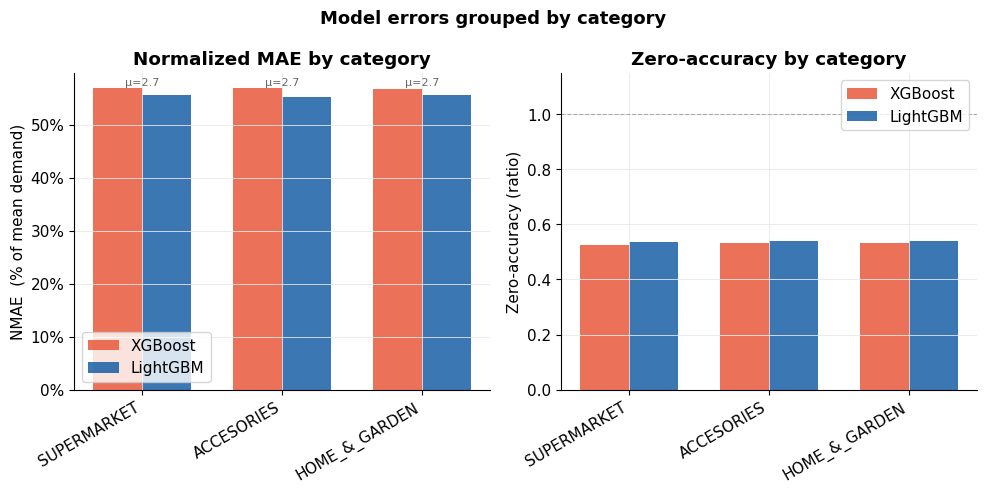

Saved → errors_by_category.png

💡 Hardest group to predict (category): 'SUPERMARKET' (XGB MAE=1.549)
   Easiest group: 'HOME_&_GARDEN' (XGB MAE=1.536)

── Per-department breakdown ──
     department  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
  SUPERMARKET_2 1173283        2.71           0.47     1.55     1.52      0.57      0.56          0.53          0.53
   ACCESORIES_2  441987        2.73           0.47     1.56     1.52      0.57      0.56          0.53          0.53
  SUPERMARKET_1  641088        2.69           0.47     1.53     1.50      0.57      0.56          0.52          0.53
HOME_&_GARDEN_1 1575990        2.71           0.47     1.54     1.51      0.57      0.56          0.53          0.54
   ACCESORIES_1 1234100        2.75           0.47     1.56     1.51      0.57      0.55          0.53          0.54
  SUPERMARKET_3 2440121        2.74           0.47     1.55     1.52      0.57      0.55          0.53          0.5

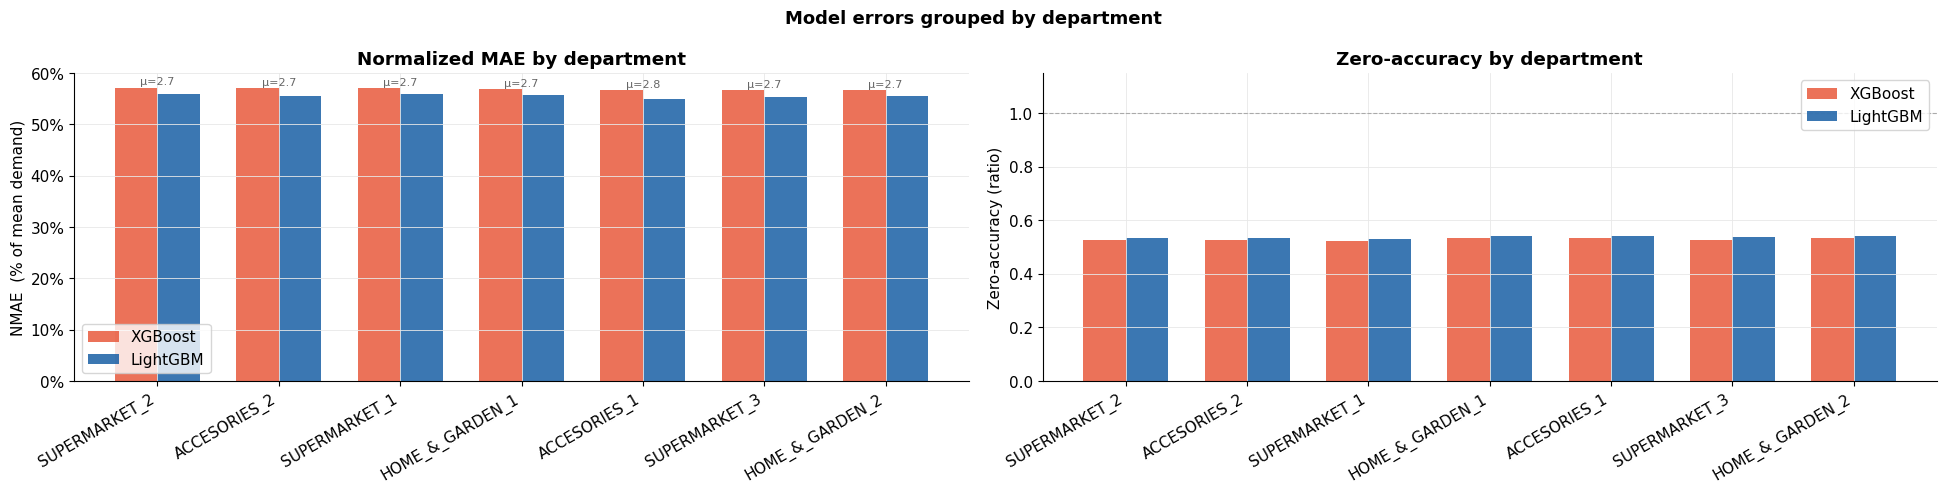

Saved → errors_by_department.png

💡 Hardest group to predict (department): 'SUPERMARKET_2' (XGB MAE=1.550)
   Easiest group: 'HOME_&_GARDEN_2' (XGB MAE=1.529)

── Per-store_code breakdown ──
store_code  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
     NYC_3  904303        2.35           0.47     1.47     1.45      0.62      0.62          0.52          0.53
     NYC_1  904423        2.47           0.48     1.44     1.41      0.58      0.57          0.54          0.55
     NYC_2  901204        2.58           0.47     1.50     1.47      0.58      0.57          0.52          0.53
     NYC_4  903267        2.59           0.48     1.50     1.48      0.58      0.57          0.54          0.55
     PHI_3  905245        2.92           0.47     1.66     1.63      0.57      0.56          0.52          0.53
     PHI_2  904400        2.63           0.47     1.48     1.47      0.56      0.56          0.54          0.55
     PHI_1  904675       

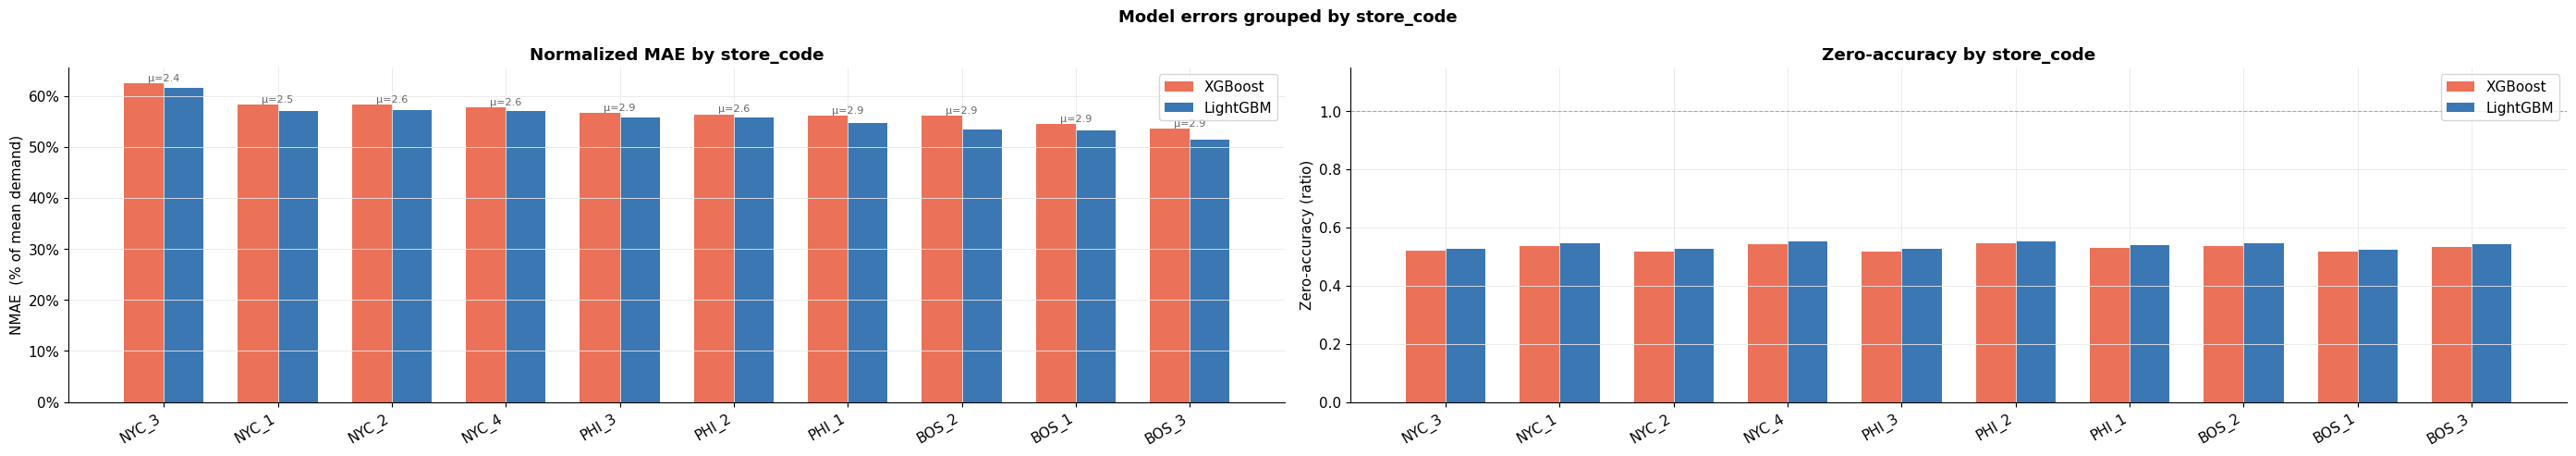

Saved → errors_by_store_code.png

💡 Hardest group to predict (store_code): 'NYC_3' (XGB MAE=1.468)
   Easiest group: 'BOS_3' (XGB MAE=1.579)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# QUICK-START EXAMPLE  (adapt paths / names as needed)
# ══════════════════════════════════════════════════════════════════════════════
 
# if __name__ == "__main__":
#     from forecast_pipeline import run_pipeline
#     import pandas as pd
 
#     DATA_PATH = "your_data.csv"
 
#     # ── run the pipeline ──────────────────────────────────────────────────────
#     results = run_pipeline(DATA_PATH)
 
#     # ── rebuild test_meta ─────────────────────────────────────────────────────
#     raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
raw = df_dsMarket.sort_values(["date", "store_code", "item"]).reset_index(drop=True)

# Re-derive which rows survived the lag warmup: we know X_test has 20% of
# the total post-drop rows. Align by positional index.
n_total   = len(daily_results["X_test"]) + int(len(daily_results["X_test"]) / 0.2 * 0.8)
lag_drop  = len(raw) - n_total          # rows lost to lag NaN warmup
split_idx = lag_drop + int(n_total * 0.8)
test_meta = raw.iloc[split_idx:].reset_index(drop=True)
 
# ── 1. Feature importance ─────────────────────────────────────────────────
#plot_feature_importance(daily_results["xgb"], daily_results["lgb"], daily_results["X_test"], top_n=20)

# ── 2. Per-group errors ───────────────────────────────────────────────────
for grp in ["category", "department", "store_code"]:
    plot_group_errors(daily_results, test_meta, group_col=grp)

# # ── 3. Single item deep-dive (replace with your actual IDs) ──────────────
# plot_item_prediction(
#     daily_results, test_meta,
#     store_code="NYC_1",
#     item_id="ACC_1_001",
#     prophet_preds=None,   # pass your Prophet prediction array here to compare
#     last_n_days=90,
# )

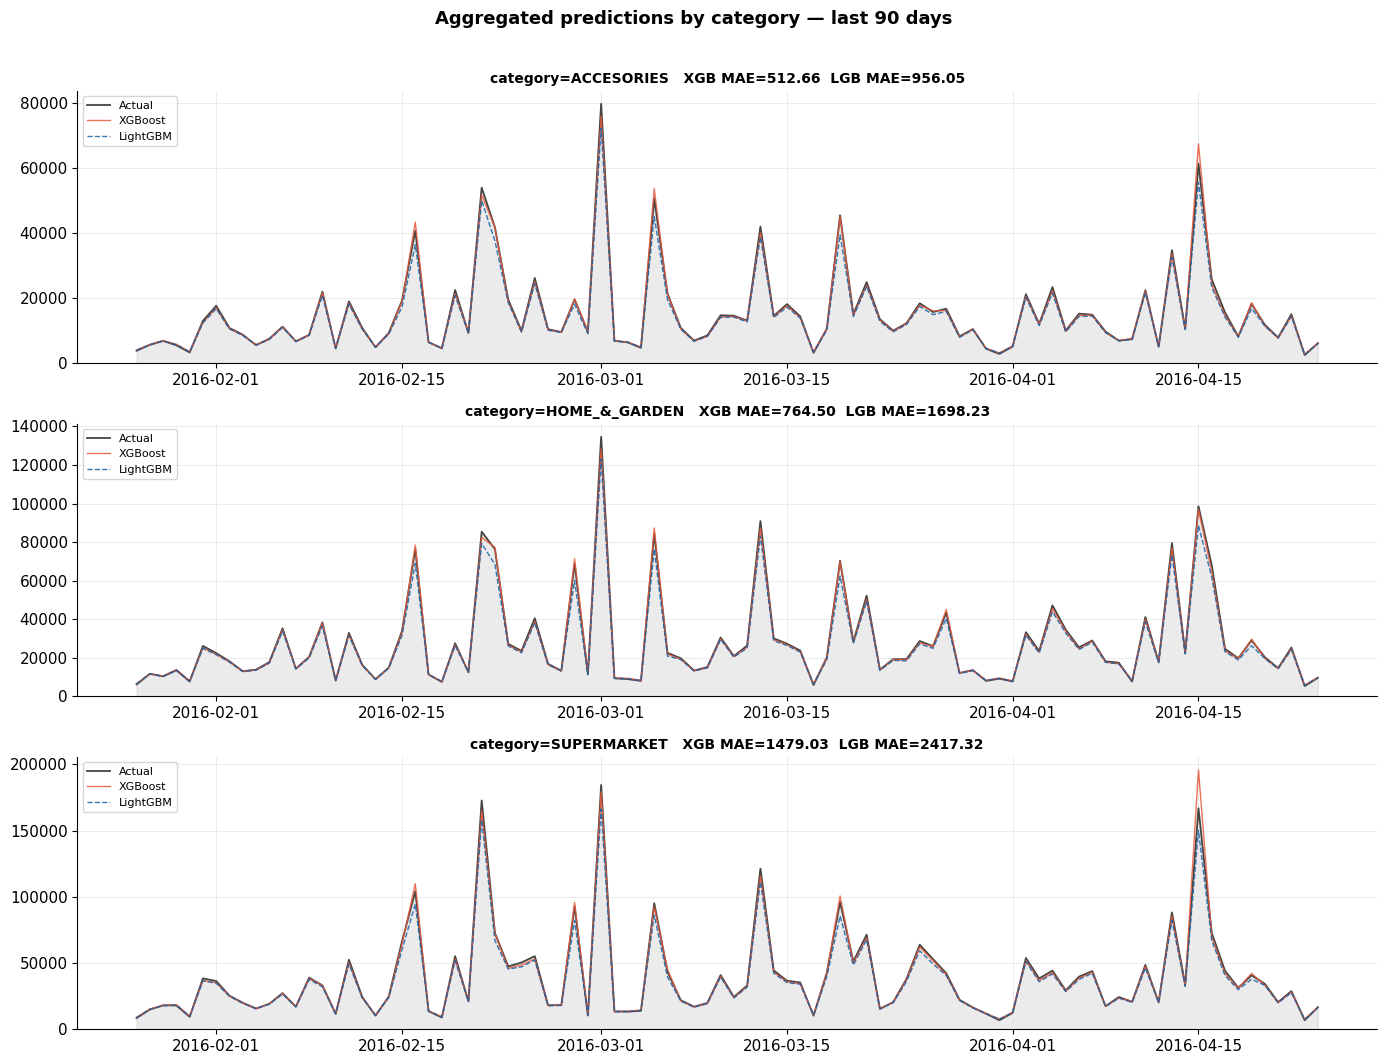

Saved → grid_by_category.png


In [149]:
# ── 3. Aggregated grid by category ───────────────────────────────────────
plot_group_predictions_grid(daily_results, test_meta, group_col="category", last_n_days=90)

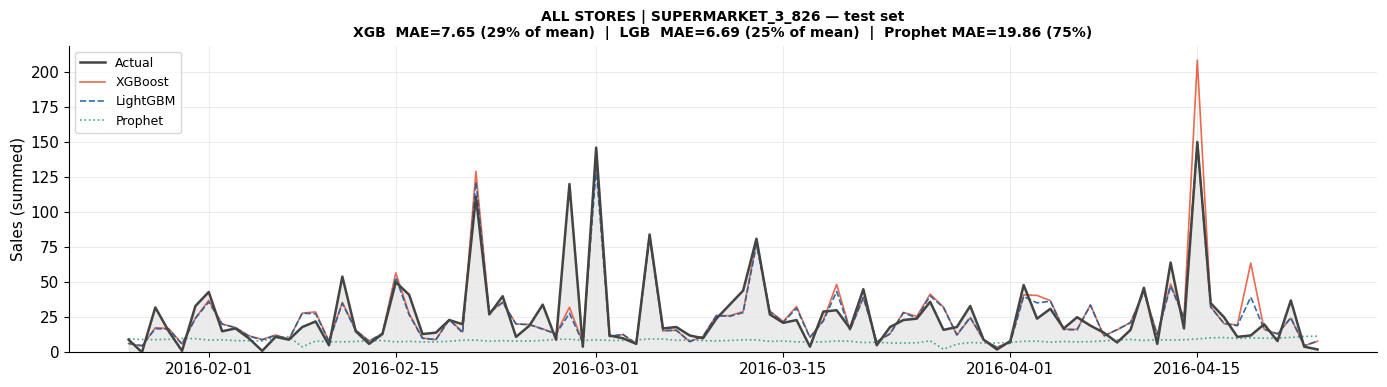

Saved → pred_ALL_SUPERMARKET_3_826.png


In [150]:
# # ── 4. Single item deep-dive (replace with your actual IDs) ──────────────
plot_item_prediction(
    daily_results, test_meta,
    store_code=None,   # set to None to aggregate across all stores for this item
    item="SUPERMARKET_3_826",
    prophet_preds=prophet_forecast["yhat"],   # pass your Prophet prediction array here to compare
    last_n_days=90,
)

## 7. Weekly Approach

In [151]:
df_dsMarket_weekly

,item,store_code,yearweek,category,department,store,region,sales,event_count,ramadan_count,first_event,first_event_dow,event_on_weekend,sell_price
0,ACCESORIES_1_001,BOS_1,201328,ACCESORIES,ACCESORIES_1,South_End,Boston,4,0,7,NoEvent,-1,0,12.74
1,ACCESORIES_1_001,BOS_1,201329,ACCESORIES,ACCESORIES_1,South_End,Boston,3,0,7,NoEvent,-1,0,10.99
2,ACCESORIES_1_001,BOS_1,201330,ACCESORIES,ACCESORIES_1,South_End,Boston,3,0,7,NoEvent,-1,0,10.99
3,ACCESORIES_1_001,BOS_1,201331,ACCESORIES,ACCESORIES_1,South_End,Boston,1,0,5,NoEvent,-1,0,10.99
4,ACCESORIES_1_001,BOS_1,201332,ACCESORIES,ACCESORIES_1,South_End,Boston,0,0,0,NoEvent,-1,0,10.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6721781,SUPERMARKET_3_827,PHI_3,201613,SUPERMARKET,SUPERMARKET_3,Queen_Village,Philadelphia,23,1,0,Easter,2,1,1.20
6721782,SUPERMARKET_3_827,PHI_3,201614,SUPERMARKET,SUPERMARKET_3,Queen_Village,Philadelphia,11,0,0,NoEvent,-1,0,1.20
6721783,SUPERMARKET_3_827,PHI_3,201615,SUPERMARKET,SUPERMARKET_3,Queen_Village,Philadelphia,1,0,0,NoEvent,-1,0,1.20
6721784,SUPERMARKET_3_827,PHI_3,201616,SUPERMARKET,SUPERMARKET_3,Queen_Village,Philadelphia,0,0,0,NoEvent,-1,0,1.20


In [160]:
"""
weekly_aggregation.py
─────────────────────
Feature engineering for a PRE-AGGREGATED weekly table.

Expected input columns
──────────────────────
  yearweek         : int, format YYYYWW  e.g. 202401 = ISO year 2024, week 1
  store_code       : e.g. 'NYC_1'
  item_id          : e.g. 'ACC_1_001'
  category         : e.g. 'ACC'
  department       : e.g. 'ACC_1'
  sales            : weekly sales (target)
  sell_price       : mean sell price for the week
  event_count      : number of days with any event in the week
  ramadan_count    : number of Ramadan days in the week
  first_event      : name of the first event ('NoEvent' if none)
  first_event_dow  : day-of-week of first event (0=Mon…6=Sun; -1 or NaN if none)
  event_on_weekend : 1 if first event falls on weekend, 0 otherwise

Output: model-ready DataFrame with date features, encoded categoricals,
lag and rolling features — ready for temporal_split() → train_*().
"""


# ── config ────────────────────────────────────────────────────────────────────
TARGET       = "sales"
GROUP_COLS   = ["store_code", "item"]
YEARWEEK_COL = "yearweek"          # integer YYYYWW

# Categoricals that need encoding (first_event is also categorical)
CAT_COLS = ["store_code", "item", "category", "department", "region", "first_event"]

# Lag distances and rolling windows — in weeks
WEEKLY_LAG_WEEKS    = [1, 2, 4, 8]    # ~1w, 2w, 1m, 2m
WEEKLY_ROLL_WINDOWS = [4, 8, 13]      # ~1m, 2m, quarter


# ── 1. Parse yearweek → date features ────────────────────────────────────────

def add_weekly_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Parse the integer YYYYWW column into temporal features, then drop it.

    ISO week parsing: '202401' → ISO year=2024, week=1.
    We convert to a real Monday date via strptime format '%G%V%u' + day '1'
    so we can extract month, quarter, and is_month_start reliably.
    week_of_year is taken directly from the integer (last 2 digits) to avoid
    any edge cases with year boundaries.
    """
    yw = df[YEARWEEK_COL].astype(str).str.zfill(6)

    year = yw.str[:4].astype(int)
    week = yw.str[4:].astype(int)

    # Fix invalid week 00 → treat as week 1 (or shift to last week prev year if you prefer)
    week = week.replace(0, 1)

    # Build a base date: Jan 1 of each year
    base_date = pd.to_datetime(year.astype(str) + "-01-01")

    # Since your weeks start on Saturday:
    # We shift to the first Saturday of the year, then add weeks
    first_saturday = base_date + pd.to_timedelta((5 - base_date.dt.weekday) % 7, unit="D")

    week_start = first_saturday + pd.to_timedelta((week - 1) * 7, unit="D")

    #df["week_of_year"]   = yw.str[4:].astype(int)     # last 2 digits = ISO week number
    df["year"]           = yw.str[:4].astype(int)
    df["month"]          = week_start.dt.month
    df["quarter"]        = week_start.dt.quarter
    df["is_month_start"] = (week_start.dt.day <= 7).astype(int)   # True in first week of month
    df["is_salary_week"] = week_start.dt.day.between(7, 15).astype(int)
    df["day_of_year"] = week_start.dt.dayofyear

    # Drop the raw yearweek — the integer itself is not meaningful to the tree
    df = df.drop(columns=[YEARWEEK_COL])
    print(f"Parsed {YEARWEEK_COL} → day_of_year, year, month, quarter, is_month_start. "
          f"Dropped {YEARWEEK_COL}.")
    return df


# ── 2. Clean event columns ────────────────────────────────────────────────────

def clean_event_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardise the five event columns from the pre-aggregated table.

    Fills NaNs with safe sentinel values and adds a binary has_event flag.
    event_on_weekend staying 0 when there is no event is fine — the model
    will learn that has_event=0 makes event_on_weekend irrelevant.
    """
    df["first_event"]      = df["first_event"].fillna("NoEvent")
    df["first_event_dow"]  = df["first_event_dow"].fillna(-1).astype(int)
    df["event_on_weekend"] = df["event_on_weekend"].fillna(0).astype(int)
    df["event_count"]      = df["event_count"].fillna(0).astype(int)
    df["ramadan_count"]    = df["ramadan_count"].fillna(0).astype(int)

    # Binary convenience flag — strong signal for the model
    df["has_event"] = (df["event_count"] > 0).astype(int)

    print(f"Event columns cleaned. "
          f"Weeks with ≥1 event: {df['has_event'].sum():,} / {len(df):,}  "
          f"| Ramadan weeks: {(df['ramadan_count'] > 0).sum():,}")
    return df


# ── 3. Encode categoricals ────────────────────────────────────────────────────

def encode_categoricals(df: pd.DataFrame):
    """
    OrdinalEncoder for all CAT_COLS present in the DataFrame.
    Returns (encoded_df, fitted_encoder).
    LightGBM will re-cast these to 'category' dtype inside train_lightgbm().
    """
    from sklearn.preprocessing import OrdinalEncoder

    existing = [c for c in CAT_COLS if c in df.columns]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    df[existing] = enc.fit_transform(df[existing]).astype(int)
    print(f"Encoded categoricals: {existing}")
    return df, enc


# ── 4. Lag features ───────────────────────────────────────────────────────────

def add_weekly_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """Shift sales back N weeks per store_code × item_id group."""
    grp = df.groupby(GROUP_COLS)[TARGET]
    for lag in WEEKLY_LAG_WEEKS:
        df[f"lag_{lag}w"] = grp.shift(lag)
    print(f"Added lag features: {[f'lag_{l}w' for l in WEEKLY_LAG_WEEKS]}")
    return df


# ── 5. Rolling features ───────────────────────────────────────────────────────

def add_weekly_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rolling mean and std over the past N weeks (shift(1) prevents leakage).
    Computed per store_code × item_id group.
    """
    for w in WEEKLY_ROLL_WINDOWS:
        shifted = df.groupby(GROUP_COLS)[TARGET].shift(1)
        df[f"roll_mean_{w}w"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
        df[f"roll_std_{w}w"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        )
    print(f"Added rolling mean/std for windows: {WEEKLY_ROLL_WINDOWS} weeks")
    return df


# ── 6. Validation ─────────────────────────────────────────────────────────────

def validate_weekly_df(df: pd.DataFrame):
    """Sanity checks and summary stats before modelling."""
    zero_frac = (df[TARGET] == 0).mean()
    print(f"\n── Weekly data validation ──")
    print(f"  Rows              : {len(df):,}")
    print(f"  Zero-sales weeks  : {zero_frac:.1%}")
    print(f"  Sales range       : {df[TARGET].min():.0f} – {df[TARGET].max():.0f}")
    print(f"  Mean weekly sales : {df[TARGET].mean():.2f}")
    if "first_event_dow" in df.columns:
        dist = df["first_event_dow"].value_counts().sort_index()
        print(f"  first_event_dow distribution (-1 = no event):\n{dist.to_string()}")

    group_counts = df.groupby(GROUP_COLS).size()
    sparse = group_counts[group_counts < 10]
    if not sparse.empty:
        print(f"\n⚠️  {len(sparse)} group(s) with <10 weeks — consider dropping:\n"
              f"{sparse.head(10)}")


# ── 7. Full pipeline ──────────────────────────────────────────────────────────

def build_weekly_dataset(df: pd.DataFrame):
    """
    Load a pre-aggregated weekly CSV and run all feature engineering steps.

    Returns (model_ready_df, encoder) — feed directly into:
        temporal_split() → split_X_y() → train_xgboost() / train_lightgbm()
    """

    # Critical: sort by time then group so lags are computed in the right order
    df = df.sort_values([YEARWEEK_COL] + GROUP_COLS).reset_index(drop=True)
    print(f"Loaded {len(df):,} rows | "
          f"yearweek {df[YEARWEEK_COL].min()} → {df[YEARWEEK_COL].max()}")

    df = add_weekly_date_features(df)    # YYYYWW → month, quarter, week_of_year, etc.
    df = clean_event_columns(df)         # fill NaNs, add has_event
    df, encoder = encode_categoricals(df)
    df = add_weekly_lag_features(df)
    df = add_weekly_rolling_features(df)
    df = drop_nan_rows(df)               # remove warmup rows from lag creation

    validate_weekly_df(df)
    return df, encoder


In [166]:
if __name__ == "__main__":

    df, encoder = build_weekly_dataset(df_dsMarket_weekly)

    train_df, test_df = temporal_split(df)
    X_train, y_train  = split_X_y(train_df)
    X_test,  y_test   = split_X_y(test_df)

    print(f"\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}\n")

    results = {
        "X_test": X_test,
        "y_test": y_test,
    }
    results["xgb"], results["xgb_preds"] = train_xgboost(X_train, y_train, X_test, y_test)
    results["lgb"], results["lgb_preds"] = train_lightgbm(X_train, y_train, X_test, y_test)

Loaded 6,721,786 rows | yearweek 201105 → 201617
Parsed yearweek → day_of_year, year, month, quarter, is_month_start. Dropped yearweek.
Event columns cleaned. Weeks with ≥1 event: 850,508 / 6,721,786  | Ramadan weeks: 619,716
Encoded categoricals: ['store_code', 'item', 'category', 'department', 'region', 'first_event']
Added lag features: ['lag_1w', 'lag_2w', 'lag_4w', 'lag_8w']
Added rolling mean/std for windows: [4, 8, 13] weeks
Dropped 243,920 NaN rows (from lag/rolling warmup). Remaining: 6,477,866

── Weekly data validation ──
  Rows              : 6,477,866
  Zero-sales weeks  : 25.0%
  Sales range       : 0 – 3539
  Mean weekly sales : 9.75
  first_event_dow distribution (-1 = no event):
first_event_dow
-1    5653310
 1      30102
 2     312101
 3      29889
 4      66918
 5      70521
 6     234652
 7      80373

⚠️  16 group(s) with <10 weeks — consider dropping:
store_code  item
1           2520    6
3           2520    7
            2819    3
4           869     3
         

In [185]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. MULTI-GROUP GRID  (quick overview across all groups at once)
# ══════════════════════════════════════════════════════════════════════════════
 
def week_plot_group_predictions_grid(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str = "category",
    last_n_weeks: int = 13,
):
    """
    One subplot per unique value of group_col, showing aggregated weekly
    actual vs predicted sales (summed across all items/stores in that group).
    """
    groups = sorted(test_meta[group_col].unique())
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = [axes]
 
    y_true   = results["y_test"].values
    xgb_pred = results["xgb_preds"]
    lgb_pred = results["lgb_preds"]

    yw = test_meta[YEARWEEK_COL].astype(str).str.zfill(6)

    year = yw.str[:4].astype(int)
    week = yw.str[4:].astype(int)

    # Fix invalid week 00 → treat as week 1 (or shift to last week prev year if you prefer)
    week = week.replace(0, 1)

    # Build a base date: Jan 1 of each year
    base_date = pd.to_datetime(year.astype(str) + "-01-01")

    # Since your weeks start on Saturday:
    # We shift to the first Saturday of the year, then add weeks
    first_saturday = base_date + pd.to_timedelta((5 - base_date.dt.weekday) % 7, unit="D")

    week_start = first_saturday + pd.to_timedelta((week - 1) * 7, unit="D")

    test_meta['week_start'] = week_start
 
    for ax, grp in zip(axes, groups):
        mask  = test_meta[group_col].values == grp
        week_start = (test_meta.loc[mask, "week_start"].values
                 if "week_start" in test_meta.columns else np.arange(mask.sum()))
 
        # aggregate by date
        tmp = pd.DataFrame({
            "week_start":   week_start,
            "actual": y_true[mask],
            "xgb":    xgb_pred[mask],
            "lgb":    lgb_pred[mask],
        })
        if "week_start" in test_meta.columns:
            tmp = tmp.groupby("week_start").sum().reset_index().tail(last_n_weeks)
 
        ax.fill_between(tmp.index if "week_start" not in tmp.columns else tmp["week_start"],
                        tmp["actual"], alpha=0.1, color=ACT_COLOR)
        x_axis = tmp["week_start"] if "week_start" in tmp.columns else tmp.index
        ax.plot(x_axis, tmp["actual"], color=ACT_COLOR, linewidth=1.3, label="Actual")
        ax.plot(x_axis, tmp["xgb"],    color=XGB_COLOR, linewidth=1,   label="XGBoost", alpha=0.85)
        ax.plot(x_axis, tmp["lgb"],    color=LGB_COLOR, linewidth=1,   label="LightGBM",
                alpha=0.85, linestyle="--")
 
        mae_xgb = mean_absolute_error(tmp["actual"], tmp["xgb"])
        mae_lgb = mean_absolute_error(tmp["actual"], tmp["lgb"])
        ax.set_title(f"{group_col}={grp}   XGB MAE={mae_xgb:.2f}  LGB MAE={mae_lgb:.2f}",
                     fontsize=10, fontweight="bold")
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper left", fontsize=8)
 
    fig.suptitle(f"Aggregated predictions by {group_col} — last {last_n_weeks} weeks",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"grid_by_{group_col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")
 

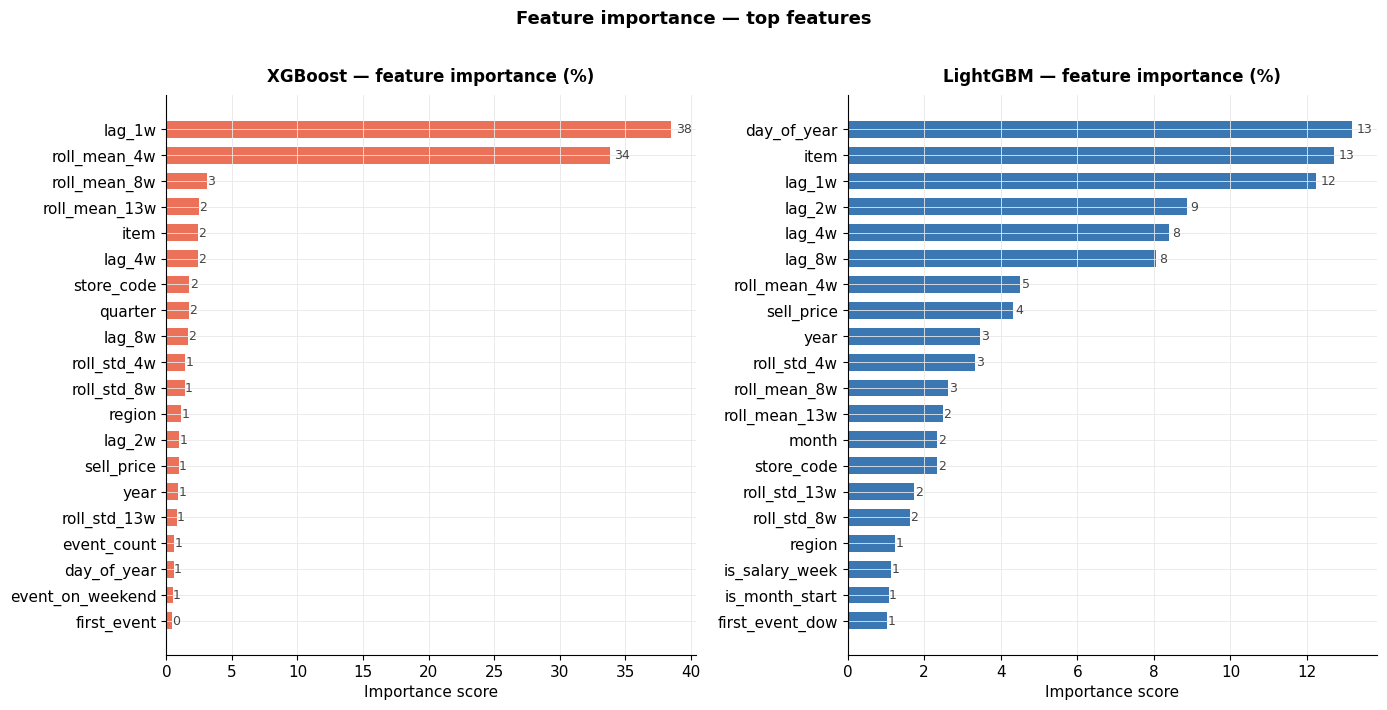

Saved → feature_importance.png

💡 Top feature XGBoost: 'lag_1w' | LightGBM: 'day_of_year'
   Lag features present in top-20: ['lag_2w', 'lag_8w', 'lag_4w', 'lag_1w']
   Rolling features present: ['roll_std_13w', 'roll_std_8w', 'roll_std_4w', 'roll_mean_13w', 'roll_mean_8w', 'roll_mean_4w']

── Per-category breakdown ──
     category  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
  SUPERMARKET  610805        9.39           0.22     3.61     3.54      0.38      0.38          0.31          0.32
HOME_&_GARDEN  444671        7.54           0.24     2.88     2.86      0.38      0.38          0.30          0.30
   ACCESORIES  240098        9.57           0.23     3.59     3.51      0.38      0.37          0.29          0.32


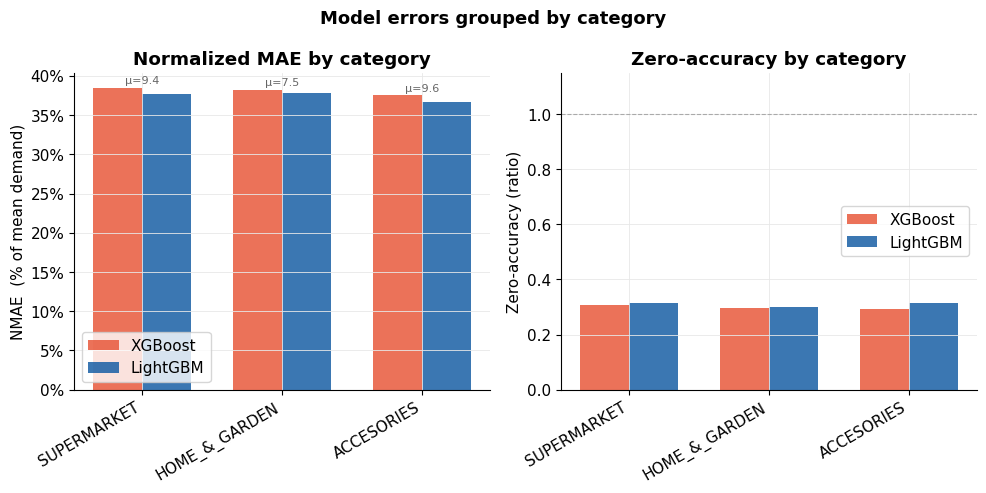

Saved → errors_by_category.png

💡 Hardest group to predict (category): 'SUPERMARKET' (XGB MAE=3.612)
   Easiest group: 'ACCESORIES' (XGB MAE=3.594)

── Per-department breakdown ──
     department  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
  SUPERMARKET_1   92016        6.25           0.27     2.68     2.68      0.43      0.43          0.35          0.34
HOME_&_GARDEN_2  218951        5.70           0.27     2.31     2.30      0.41      0.40          0.32          0.31
  SUPERMARKET_2  168519        7.88           0.22     3.18     3.12      0.40      0.40          0.32          0.31
   ACCESORIES_2   63319        8.17           0.28     3.19     3.12      0.39      0.38          0.30          0.33
  SUPERMARKET_3  350270       10.94           0.20     4.06     3.96      0.37      0.36          0.29          0.31
   ACCESORIES_1  176779       10.08           0.22     3.74     3.65      0.37      0.36          0.29          0.31
H

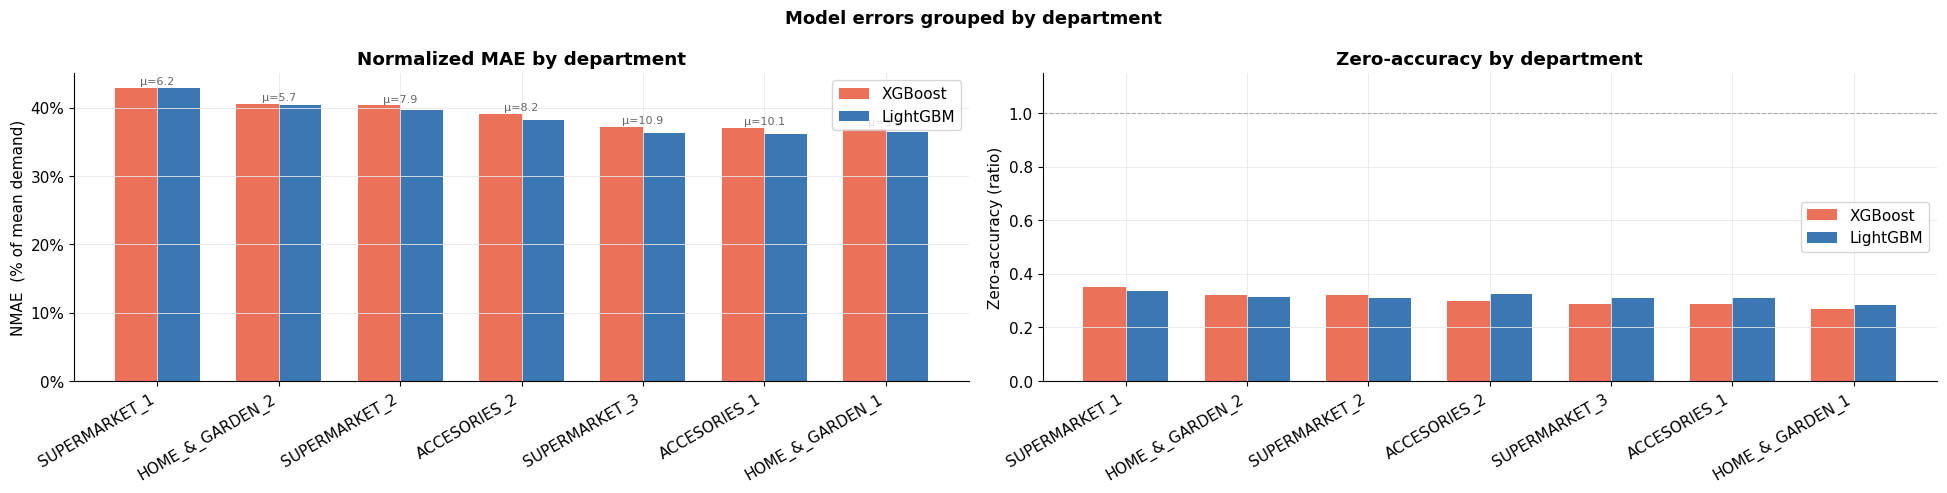

Saved → errors_by_department.png

💡 Hardest group to predict (department): 'SUPERMARKET_1' (XGB MAE=2.684)
   Easiest group: 'HOME_&_GARDEN_1' (XGB MAE=3.436)

── Per-store_code breakdown ──
store_code  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
     BOS_1  127990        7.38           0.26     2.98     2.92      0.40      0.40          0.31          0.33
     PHI_3  131070        8.26           0.27     3.29     3.22      0.40      0.39          0.33          0.34
     PHI_2  130951        9.61           0.25     3.80     3.70      0.40      0.38          0.33          0.33
     BOS_2  127973        8.03           0.22     3.17     3.14      0.40      0.39          0.28          0.28
     PHI_1  130992        7.40           0.21     2.86     2.84      0.39      0.38          0.30          0.31
     BOS_3  127904        8.37           0.25     3.23     3.15      0.39      0.38          0.30          0.32
     NYC_4  130804       

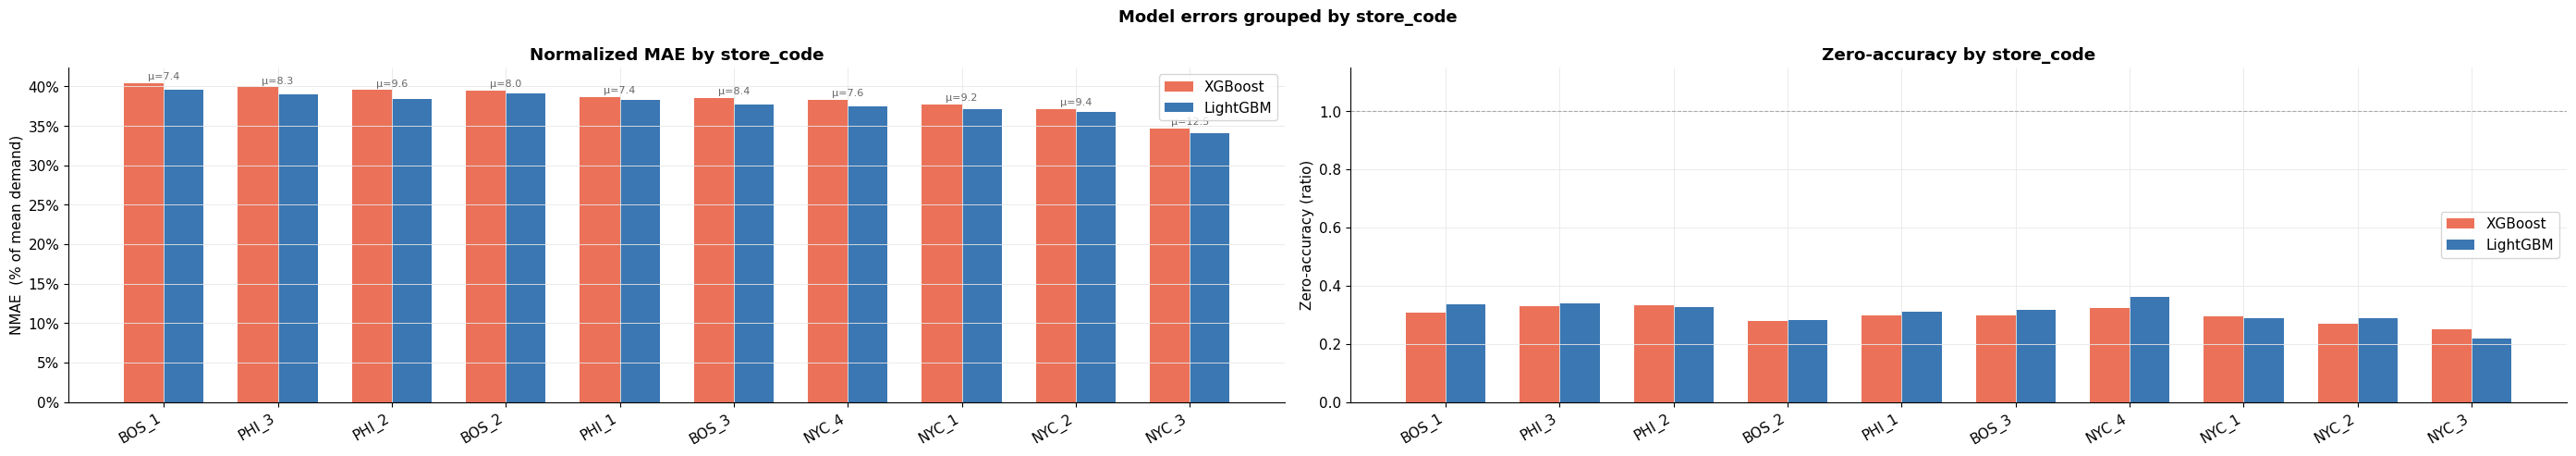

Saved → errors_by_store_code.png

💡 Hardest group to predict (store_code): 'BOS_1' (XGB MAE=2.982)
   Easiest group: 'NYC_3' (XGB MAE=4.329)


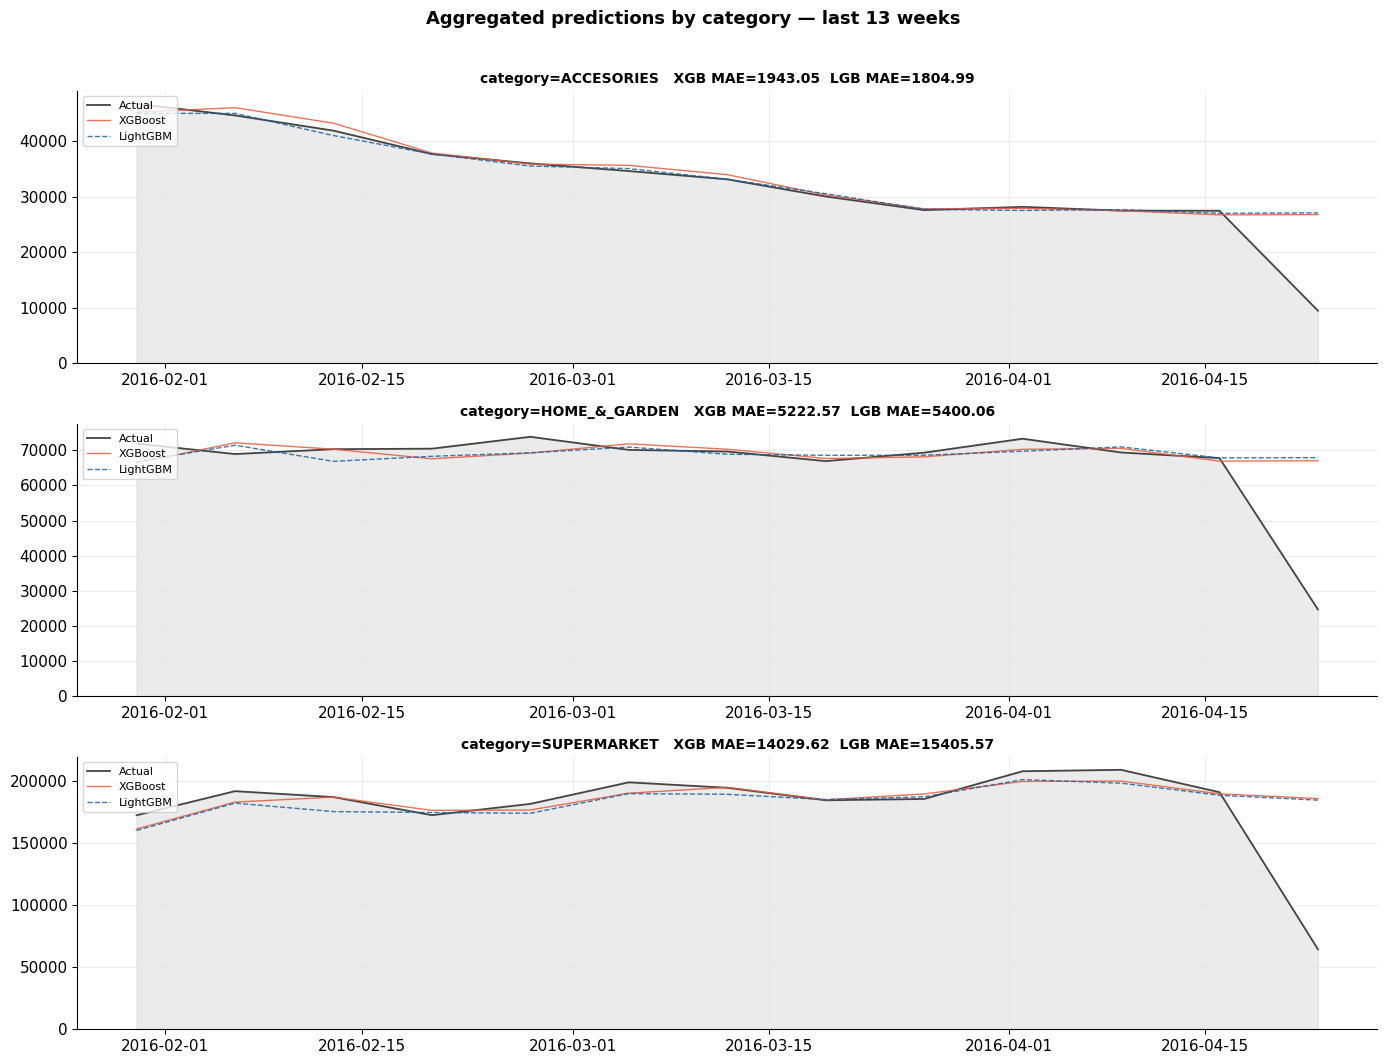

Saved → grid_by_category.png


In [186]:
# ══════════════════════════════════════════════════════════════════════════════
# QUICK-START EXAMPLE  (adapt paths / names as needed)
# ══════════════════════════════════════════════════════════════════════════════
 
raw = df_dsMarket_weekly.sort_values(["yearweek", "store_code", "item"]).reset_index(drop=True)

# Re-derive which rows survived the lag warmup: we know X_test has 20% of
# the total post-drop rows. Align by positional index.
n_total   = len(results["X_test"]) + int(len(results["X_test"]) / 0.2 * 0.8)
lag_drop  = len(raw) - n_total          # rows lost to lag NaN warmup
split_idx = lag_drop + int(n_total * 0.8)
test_meta_weekly = raw.iloc[split_idx:].reset_index(drop=True)
 
# ── 1. Feature importance ─────────────────────────────────────────────────
plot_feature_importance(results["xgb"], results["lgb"], results["X_test"], top_n=20)

# ── 2. Per-group errors ───────────────────────────────────────────────────
for grp in ["category", "department", "store_code"]:
    plot_group_errors(results, test_meta = test_meta_weekly, group_col=grp)

# ── 3. Aggregated grid by category ───────────────────────────────────────
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="category", last_n_weeks=13)

# # ── 4. Single item deep-dive (replace with your actual IDs) ──────────────
# plot_item_prediction(
#     daily_results, test_meta_weekly,
#     store_code="NYC_1",
#     item_id="ACC_1_001",
#     prophet_preds=None,   # pass your Prophet prediction array here to compare
#     last_n_days=90,
# )

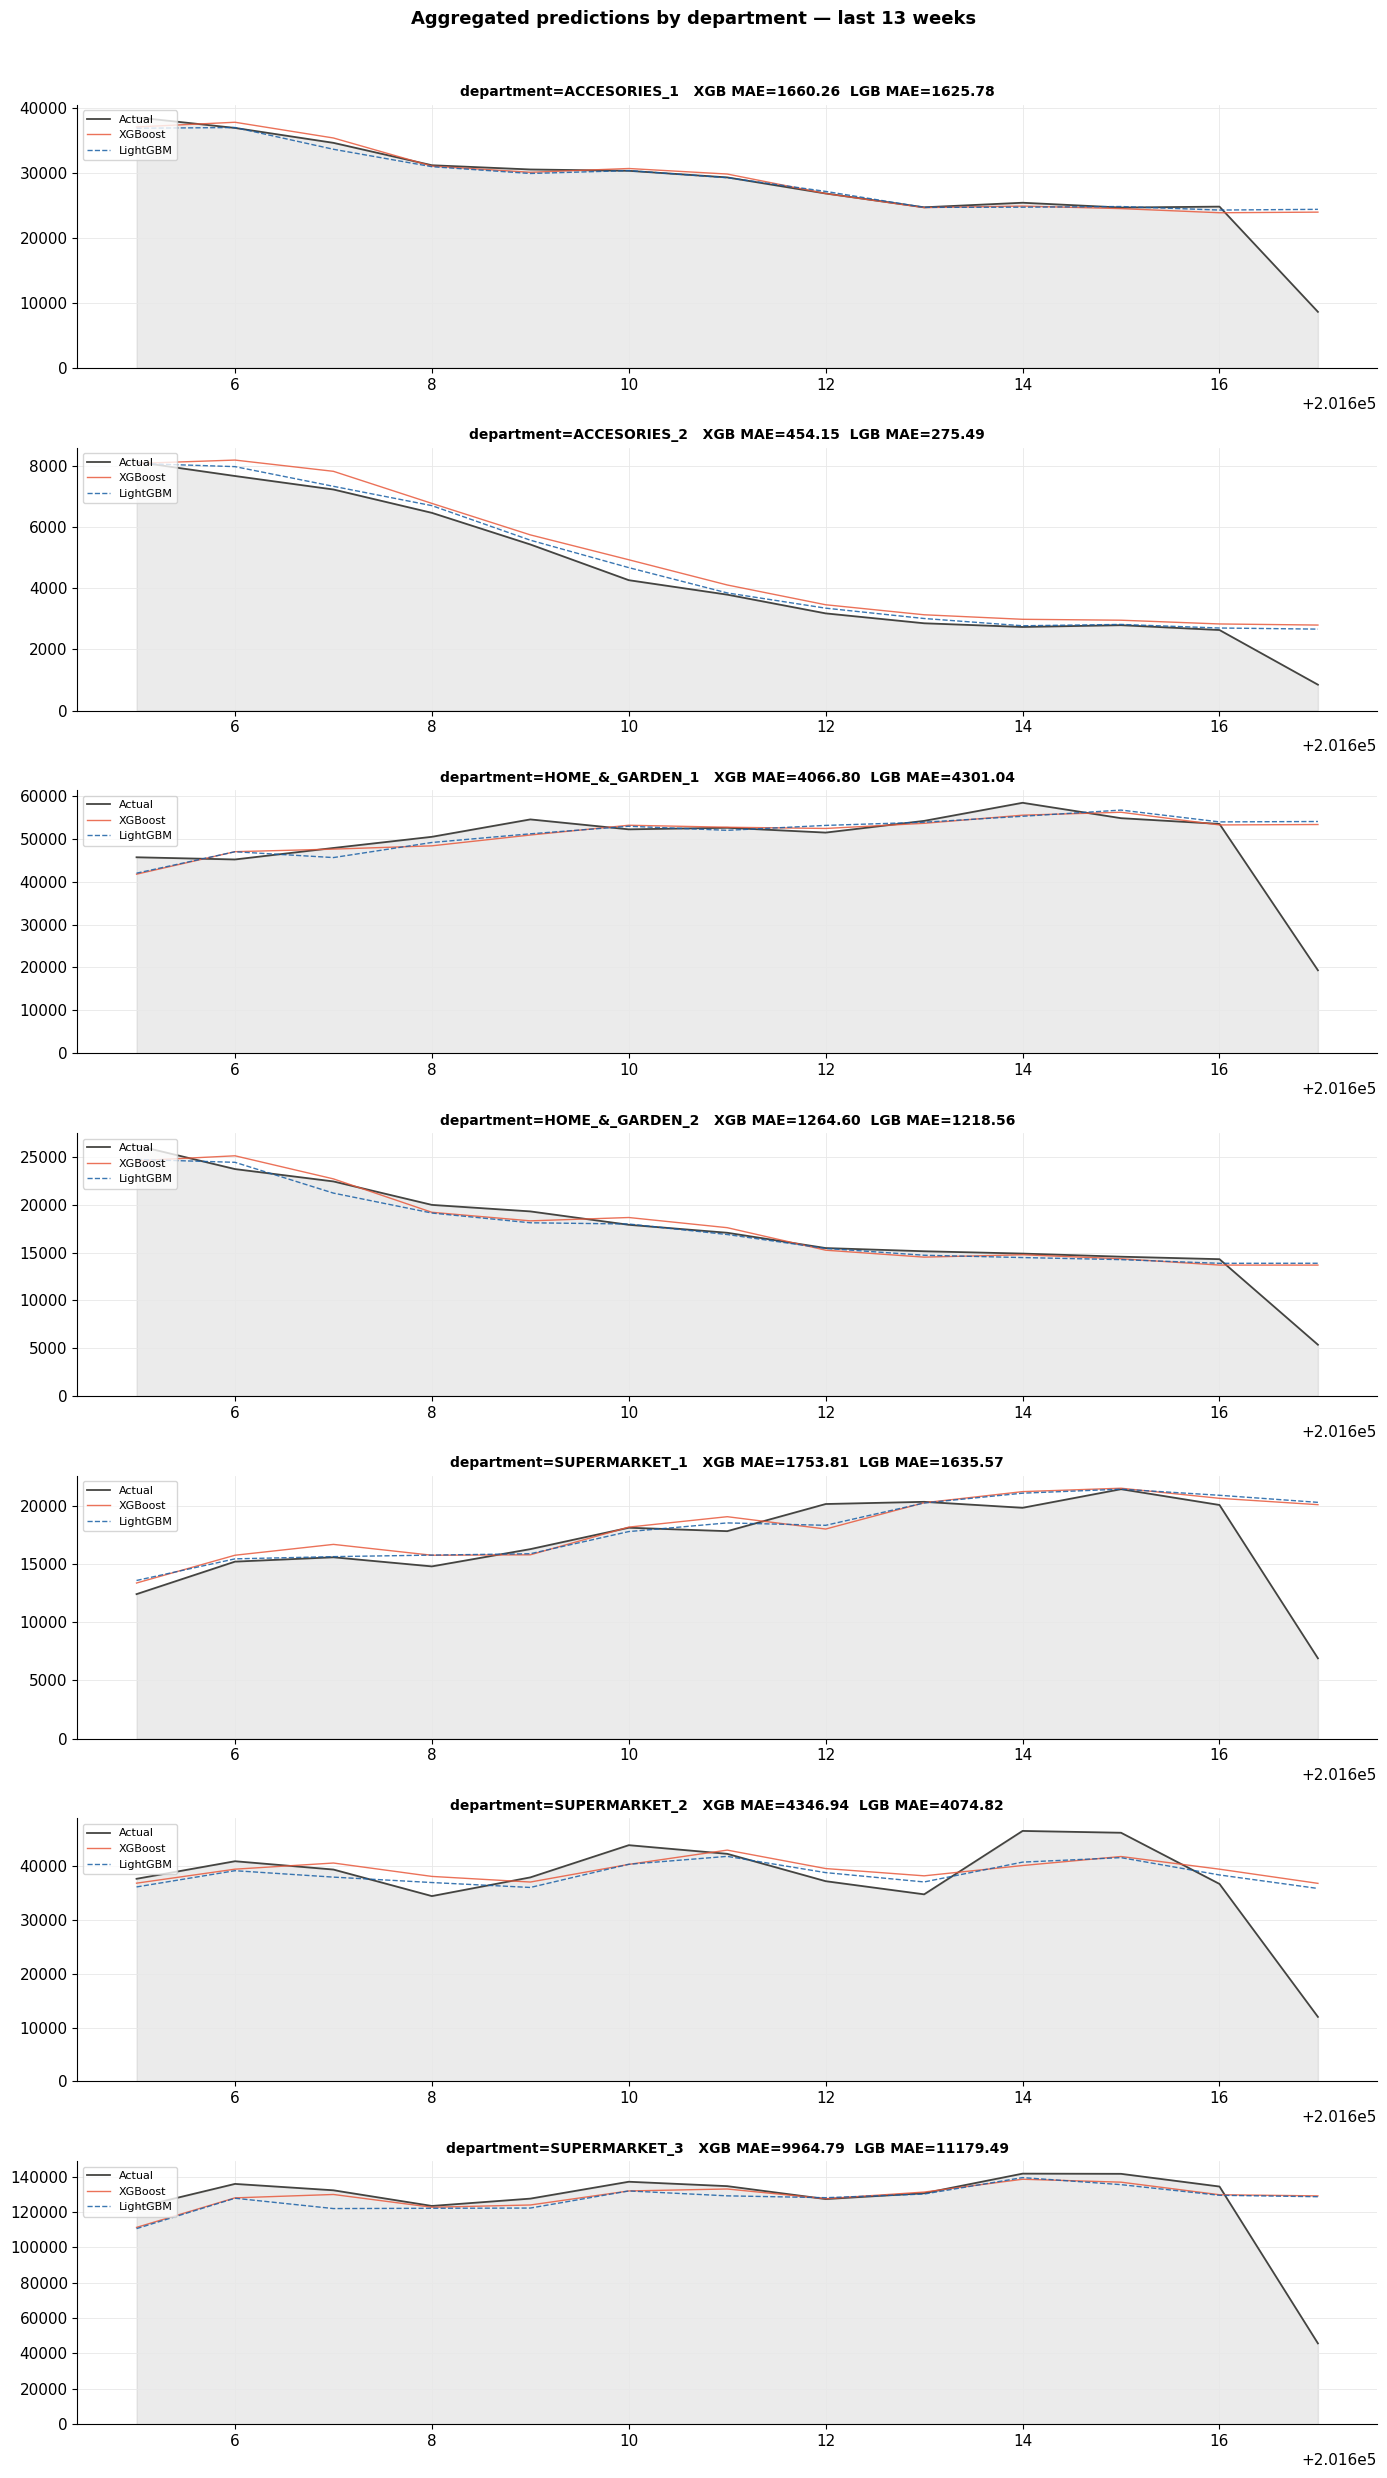

Saved → grid_by_department.png


In [182]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="department", last_n_weeks=13)

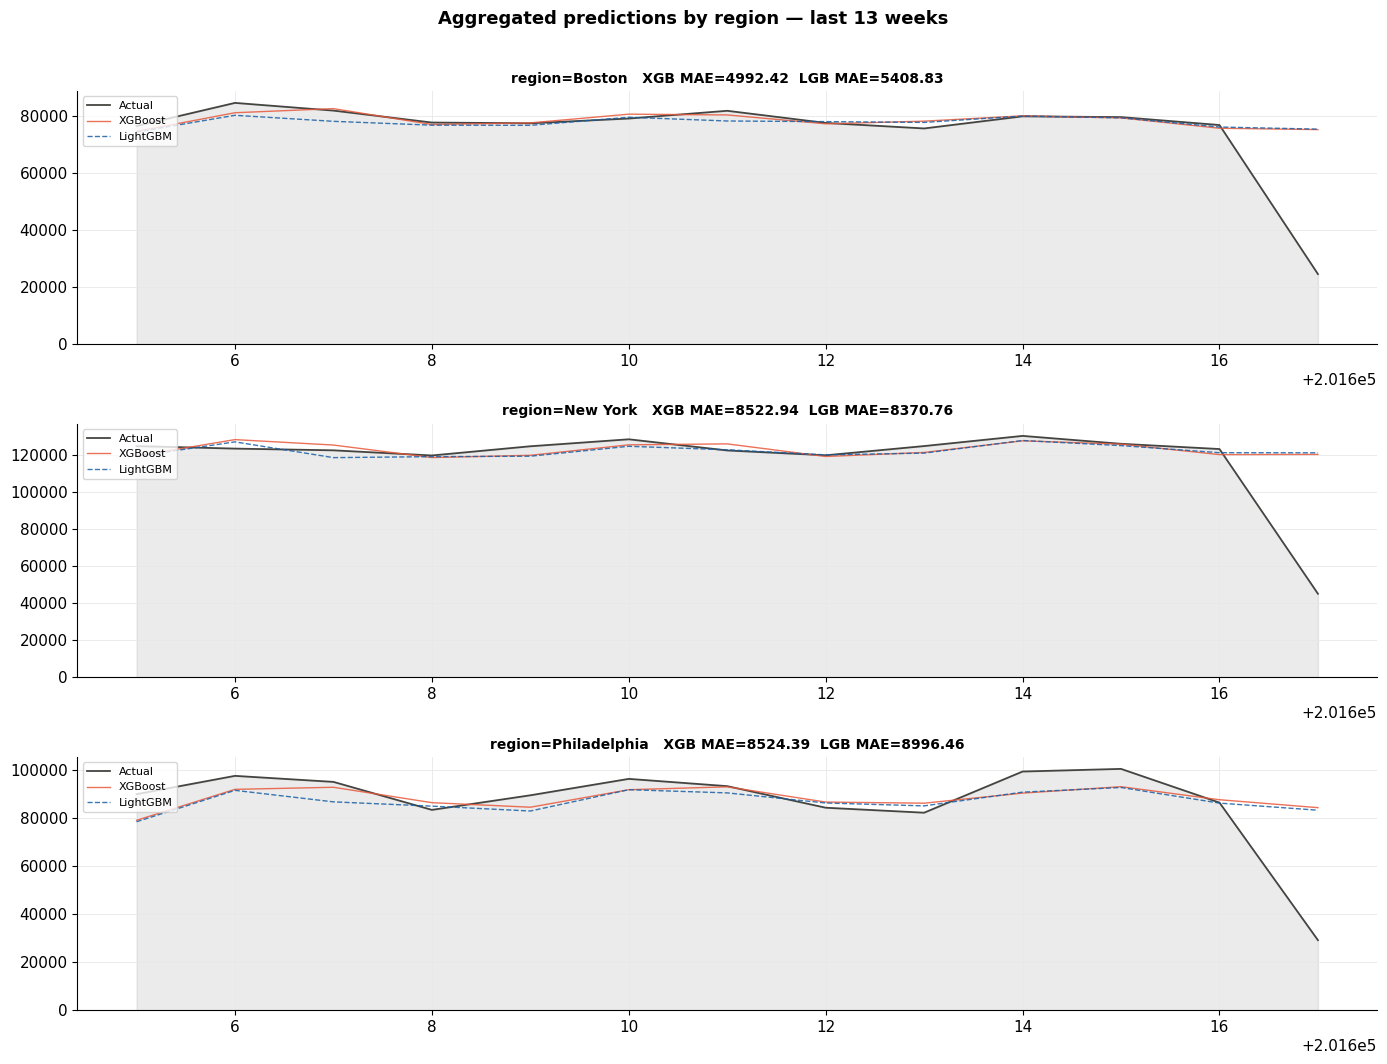

Saved → grid_by_region.png


In [183]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="region", last_n_weeks=13)

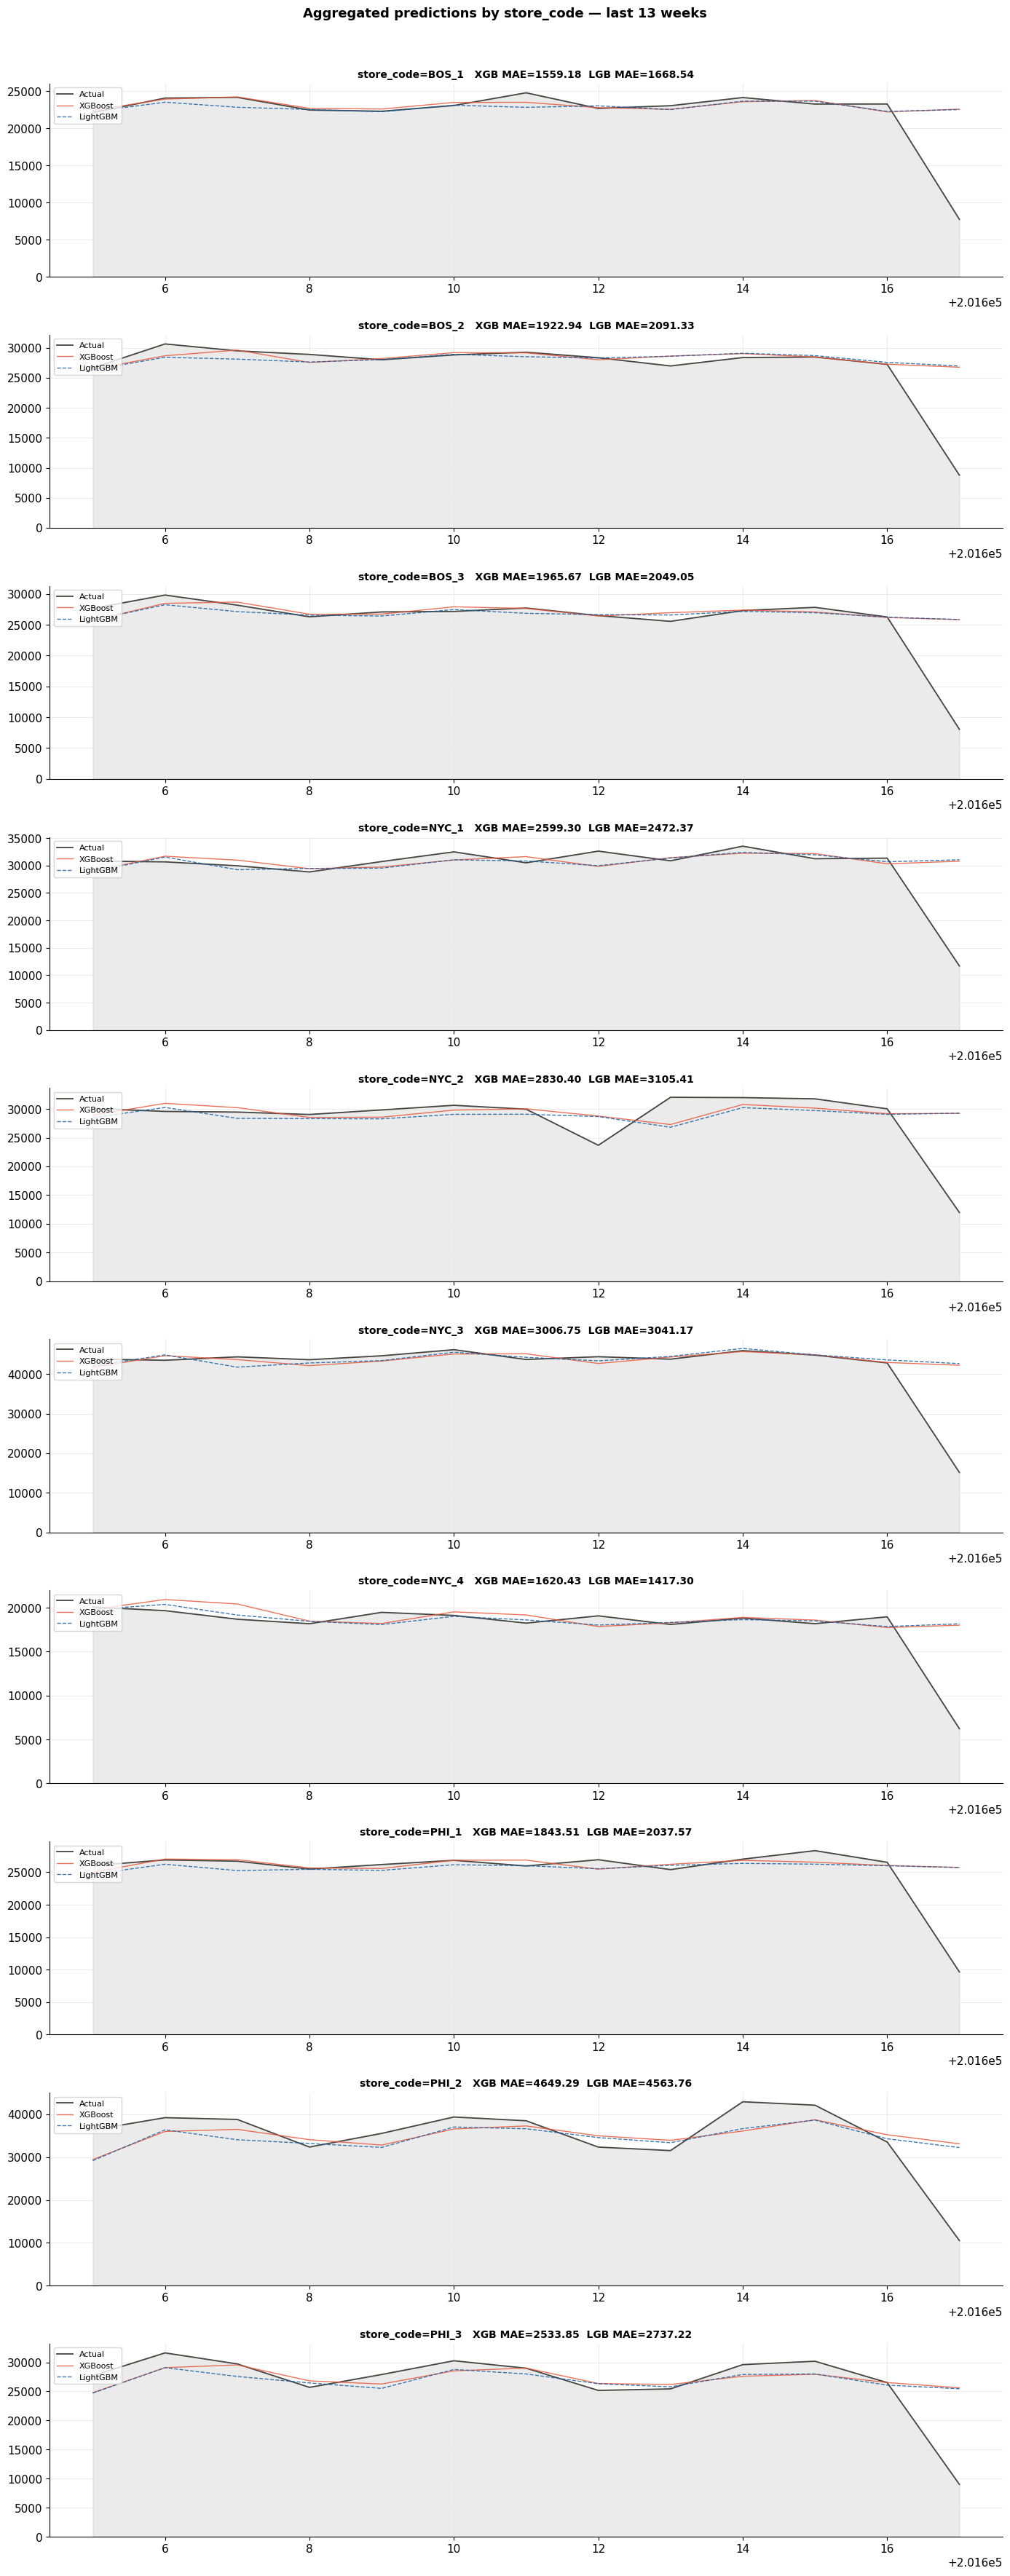

Saved → grid_by_store_code.png


In [184]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="store_code", last_n_weeks=13)